# Tas vs Tas

Historical

Figure saved as 'Global_vs_Regional_Temp_Winter0.png'


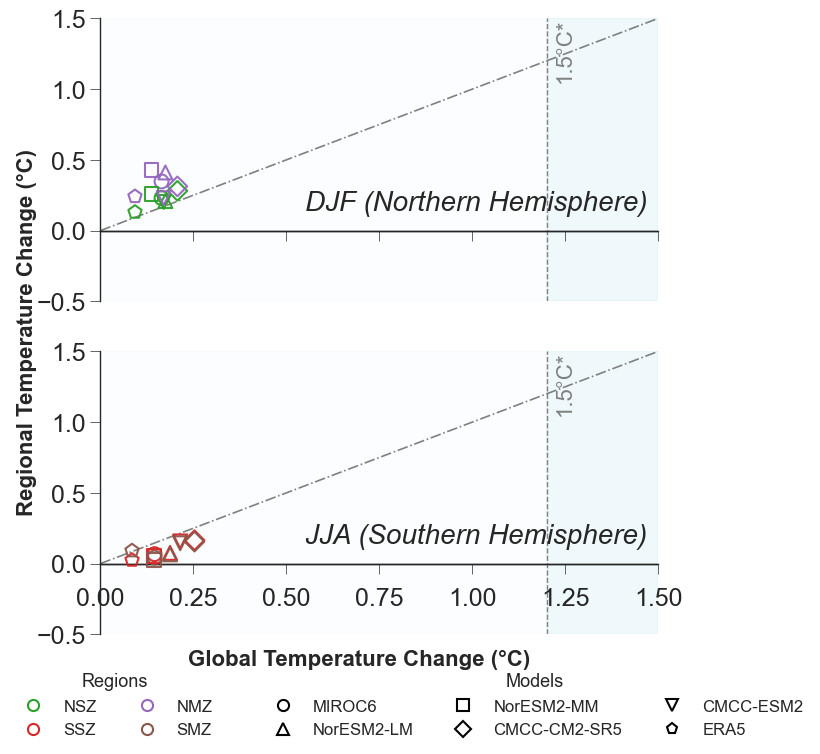

In [44]:
# with legend 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSTas.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"] == "Historical"]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 7), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "DJF: Northern Hemisphere"
    },
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "JJA: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_°C"]

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.5, alpha=0.6, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_°C"],
                marker=marker,
                s=100,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95,
                zorder=3          # Make sure markers are on top
            )

    x_max = 1.5
    y_min = -0.50
    y_max = 1.5
    xticks = np.arange(0, x_max + 0.01, 0.25)
    yticks = np.arange(y_min, y_max + 0.01, 0.5)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.plot([0, x_max], [0, y_max], '-.', color='gray', linewidth=1.2, label="1:1 Reference")
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=2)
    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1, zorder=2)
    
    ax.text(1.2 + 0.02, 1.5, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')

    # === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Move X-axis to Y=0
    ax.spines['bottom'].set_position(('data', 0))
    
    ax.tick_params(axis='both', which='major', length=7, width=0.5, direction='out', labelsize=18)
    # Move X-axis tick labels to Y=0
    ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0
    ax.grid(False)

# === ANNOTATIONS FOR SEASONS ===
axs[0].text(0.98, 0.3, 'DJF (Northern Hemisphere)', transform=axs[0].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')
axs[1].text(0.98, 0.3, 'JJA (Southern Hemisphere)', transform=axs[1].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')

# === Create Legend Elements ===
# Region colors legend
region_legend = [
    Line2D([0], [0], marker='o', color='w', label='NSZ',
           markerfacecolor='none', markeredgecolor=region_colors['Subtropics_N'], 
           markersize=8, markeredgewidth=1.5, linestyle='None'),
    Line2D([0], [0], marker='o', color='w', label='SSZ',
           markerfacecolor='none', markeredgecolor=region_colors['Subtropics_S'], 
           markersize=8, markeredgewidth=1.5, linestyle='None'),
    Line2D([0], [0], marker='o', color='w', label='NMZ',
           markerfacecolor='none', markeredgecolor=region_colors['Mid_Latitudes_N'], 
           markersize=8, markeredgewidth=1.5, linestyle='None'),
    Line2D([0], [0], marker='o', color='w', label='SMZ',
           markerfacecolor='none', markeredgecolor=region_colors['Mid_Latitudes_S'], 
           markersize=8, markeredgewidth=1.5, linestyle='None'),
]

# Model markers legend
model_legend = [
    Line2D([0], [0], marker=marker, color='w', label=model,
           markerfacecolor='none', markeredgecolor='black', 
           markersize=8, markeredgewidth=1.5, linestyle='None')
    for model, marker in model_markers.items()
]

# Add legends below the subplots
legend1 = fig.legend(handles=region_legend, loc='lower center', 
                     bbox_to_anchor=(0.15, -0.1), ncol=2, frameon=False, 
                     fontsize=12, title='Regions', title_fontsize=13)
legend2 = fig.legend(handles=model_legend, loc='lower center', 
                     bbox_to_anchor=(0.75, -0.1), ncol=3, frameon=False, 
                     fontsize=12, title='Models', title_fontsize=13)

# Add shared axis labels
fig.text(0.5, 0.025, 'Global Temperature Change (°C)', 
         ha='center', fontweight='bold', fontsize=16)
fig.text(0.01, 0.5, 'Regional Temperature Change (°C)', 
         va='center', rotation='vertical', fontweight='bold', fontsize=16)

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_vs_Regional_Temp_Winter0.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_vs_Regional_Temp_Winter0.png'")
plt.show()

Figure saved as 'Global_vs_Regional_Temp_Winter0.png'


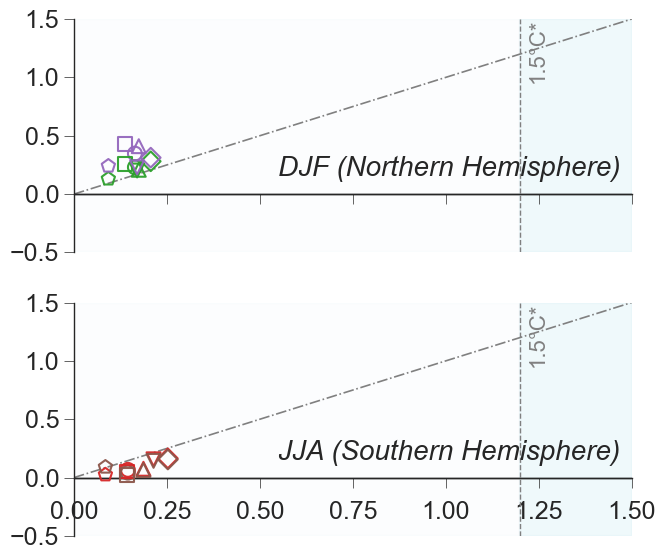

In [47]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSTas.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"] == "Historical"]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "DJF: Northern Hemisphere"
    },
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "JJA: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_°C"]

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.5, alpha=0.6, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_°C"],
                marker=marker,
                s=100,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95,
                zorder=3          # Make sure markers are on top
            )

    x_max = 1.5
    y_min = -0.50
    y_max = 1.5
    xticks = np.arange(0, x_max + 0.01, 0.25)
    yticks = np.arange(y_min, y_max + 0.01, 0.5)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.plot([0, x_max], [0, y_max], '-.', color='gray', linewidth=1.2, label="1:1 Reference")
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=2)
    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1, zorder=2)
    
    ax.text(1.2 + 0.02, 1.5, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')

    # === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Move X-axis to Y=0
    ax.spines['bottom'].set_position(('data', 0))
    
    ax.tick_params(axis='both', which='major', length=7, width=0.5, direction='out', labelsize=18)
    # Move X-axis tick labels to Y=0
    ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0
    ax.grid(False)

# === ANNOTATIONS FOR SEASONS ===
axs[0].text(0.98, 0.3, 'DJF (Northern Hemisphere)', transform=axs[0].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')
axs[1].text(0.98, 0.3, 'JJA (Southern Hemisphere)', transform=axs[1].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')

# === Create Legend Elements ===
# Region colors legend
region_legend = [
    Line2D([0], [0], marker='o', color='w', label='NSZ',
           markerfacecolor='none', markeredgecolor=region_colors['Subtropics_N'], 
           markersize=8, markeredgewidth=1.5, linestyle='None'),
    Line2D([0], [0], marker='o', color='w', label='SSZ',
           markerfacecolor='none', markeredgecolor=region_colors['Subtropics_S'], 
           markersize=8, markeredgewidth=1.5, linestyle='None'),
    Line2D([0], [0], marker='o', color='w', label='NMZ',
           markerfacecolor='none', markeredgecolor=region_colors['Mid_Latitudes_N'], 
           markersize=8, markeredgewidth=1.5, linestyle='None'),
    Line2D([0], [0], marker='o', color='w', label='SMZ',
           markerfacecolor='none', markeredgecolor=region_colors['Mid_Latitudes_S'], 
           markersize=8, markeredgewidth=1.5, linestyle='None'),
]

# Model markers legend
model_legend = [
    Line2D([0], [0], marker=marker, color='w', label=model,
           markerfacecolor='none', markeredgecolor='black', 
           markersize=8, markeredgewidth=1.5, linestyle='None')
    for model, marker in model_markers.items()
]

# Add shared axis labels
#fig.text(0.5, 0.02, 'Global Temperature Change (°C)', 
#         ha='center', fontweight='bold', fontsize=16)
#fig.text(0.01, 0.5, 'Regional Temperature Change (°C)', 
#         va='center', rotation='vertical', fontweight='bold', fontsize=16)
         
# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_vs_Regional_Temp_Winter0.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_vs_Regional_Temp_Winter0.png'")
plt.show()

Figure saved as 'Global_vs_Regional_Temp_Summer0.png'


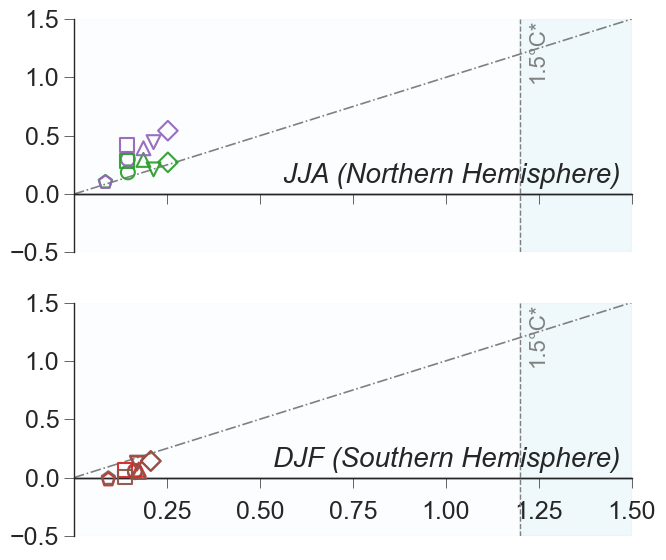

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSTas.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"] == "Historical"]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "JJA: Northern Hemisphere"
    },
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "DJF: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_°C"]

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.5, alpha=0.6, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_°C"],
                marker=marker,
                s=100,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95,
                zorder=3          # Make sure markers are on top
            )

    x_max = 1.5
    y_min = -0.5
    y_max = 1.5
    xticks = np.arange(0.25, x_max + 0.01, 0.25)
    yticks = np.arange(y_min, y_max + 0.01, 0.5)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.plot([0, x_max], [0, y_max], '-.', color='gray', linewidth=1.2, label="1:1 Reference")
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=2)
    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1, zorder=2)
    
    ax.text(1.2 + 0.02, 1.5, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')

    # === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Move X-axis to Y=0
    ax.spines['bottom'].set_position(('data', 0))
    
    ax.tick_params(axis='both', which='major', length=7, width=0.5, direction='out', labelsize=18)
    # Move X-axis tick labels to Y=0
    ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0
    ax.grid(False)

# === ANNOTATIONS FOR SEASONS ===
axs[0].text(0.98, 0.27, 'JJA (Northern Hemisphere)', transform=axs[0].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')
axs[1].text(0.98, 0.27, 'DJF (Southern Hemisphere)', transform=axs[1].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')

# Add shared axis labels
#fig.text(0.5, 0.02, 'Global Temperature Change (°C)', 
#         ha='center', fontweight='bold', fontsize=16)
#fig.text(0.01, 0.5, 'Regional Temperature Change (°C)', 
#         va='center', rotation='vertical', fontweight='bold', fontsize=16)

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_vs_Regional_Temp_Summer0.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_vs_Regional_Temp_Summer0.png'")
plt.show()

Midterm

Figure saved as 'Global_vs_Regional_Temp_Winter1.png'


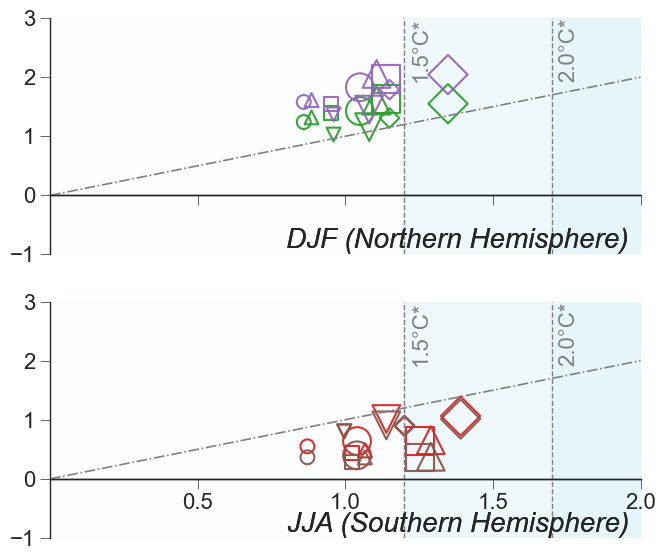

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSTas.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"].isin(["126_Midterm", "585_Midterm"])]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    #'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Midterm': 100,   # Smaller size for 126_Midterm
    '585_Midterm': 400    # Larger size for 585_Midterm
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "DJF: Northern Hemisphere"
    },
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "JJA: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_°C"]
data_max = max(x_all.max(), y_all.max(), 2.0)

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
    ax.axvspan(1.7, 2.0, alpha=1, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # Get size based on period
            size = period_sizes.get(row["Period"], 40)
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_°C"],
                marker=marker,
                s=size,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95
            )

    x_max = 2
    y_min = -1
    y_max = 3
    xticks = np.arange(0.5, x_max + 0.01, 0.5)
    yticks = np.arange(y_min, y_max + 0.01, 1)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    # === REMOVE FRAME - keep only X and Y axes ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Keep baseline at Y=0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

    # Move X-axis and its labels to Y=0
    ax.spines['bottom'].set_position('zero')  # Move X-axis to Y=0
    ax.tick_params(axis='x', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)
    ax.tick_params(axis='y', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)

    # Inline labels at end of lines
    ax.text(1.2 + 0.02, 3, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
    ax.text(1.7 + 0.02, 3, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

    ax.plot([0, x_max], [0, x_max], '-.', color='gray', linewidth=1.2, label="1:1 Reference")
    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1)

    #ax.set_title(setting["title"], fontsize=16)

    # === ANNOTATIONS FOR SEASONS ===
    axs[0].text(0.98, 0.001, 'DJF (Northern Hemisphere)', transform=axs[0].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')
    axs[1].text(0.98, 0.001, 'JJA (Southern Hemisphere)', transform=axs[1].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')

    ax.grid(False)

# === Shared Legend BELOW plots ===
region_legend = [
    Line2D([0], [0], marker='o', color='w', label=region,
           markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
    for region, color in region_colors.items()
]

reference_legend = [
    Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limit (1.5°C and 2.0°C)"),
    Line2D([0], [0], color='black', linestyle='-', label="Y=0 Baseline"),
]

# Add shared axis labels
#fig.text(0.5, 0.02, 'Global Temperature Change (°C)', 
#         ha='center', fontweight='bold', fontsize=16)
#fig.text(0.01, 0.5, 'Regional Temperature Change (°C)', 
#         va='center', rotation='vertical', fontweight='bold', fontsize=16)

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_vs_Regional_Temp_Winter1.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_vs_Regional_Temp_Winter1.png'")
plt.show()

Figure saved as 'Global_vs_Regional_Temp_Summer1.png'


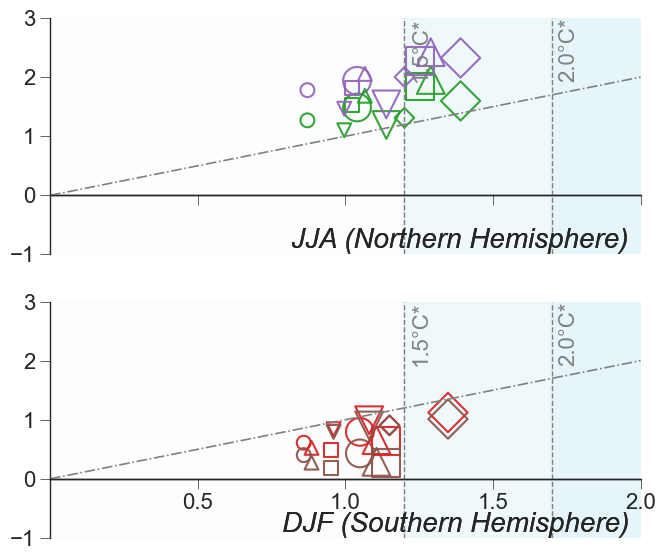

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSTas.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"].isin(["126_Midterm", "585_Midterm"])]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Midterm': 100,   # Smaller size for 126_Midterm
    '585_Midterm': 400    # Larger size for 585_Midterm
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "JJA: Northern Hemisphere"
    },
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "DJF: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_°C"]
data_max = max(x_all.max(), y_all.max(), 2.0)

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
    ax.axvspan(1.7, 2.0, alpha=1, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # Get size based on period
            size = period_sizes.get(row["Period"], 40)
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_°C"],
                marker=marker,
                s=size,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95
            )

    x_max = 2
    y_min = -1
    y_max = 3
    xticks = np.arange(0.5, x_max + 0.01, 0.5)
    yticks = np.arange(y_min, y_max + 0.01, 1)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    # === REMOVE FRAME - keep only X and Y axes ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Keep baseline at Y=0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

    # Move X-axis and its labels to Y=0
    ax.spines['bottom'].set_position('zero')  # Move X-axis to Y=0
    ax.tick_params(axis='x', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)
    ax.tick_params(axis='y', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)

    # Inline labels at end of lines
    ax.text(1.2 + 0.02, 3, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
    ax.text(1.7 + 0.02, 3, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

    ax.plot([0, x_max], [0, x_max], '-.', color='gray', linewidth=1.2, label="1:1 Reference")
    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1)

    #ax.set_title(setting["title"], fontsize=16)

    # === ANNOTATIONS FOR SEASONS ===
    axs[0].text(0.98, 0.001, 'JJA (Northern Hemisphere)', transform=axs[0].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')
    axs[1].text(0.98, 0.001, 'DJF (Southern Hemisphere)', transform=axs[1].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')

    ax.grid(False)

# === Shared Legend BELOW plots ===
region_legend = [
    Line2D([0], [0], marker='o', color='w', label=region,
           markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
    for region, color in region_colors.items()
]

reference_legend = [
    Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limit (1.5°C and 2.0°C)"),
    Line2D([0], [0], color='black', linestyle='-', label="Y=0 Baseline"),
]

# Add shared axis labels
#fig.text(0.5, 0.02, 'Global Temperature Change (°C)', 
#         ha='center', fontweight='bold', fontsize=16)
#fig.text(0.01, 0.5, 'Regional Temperature Change (°C)', 
#         va='center', rotation='vertical', fontweight='bold', fontsize=16)
         
# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_vs_Regional_Temp_Summer1.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_vs_Regional_Temp_Summer1.png'")
plt.show()

Longterm

Figure saved as 'Global_vs_Regional_Temp_Winter2.png'


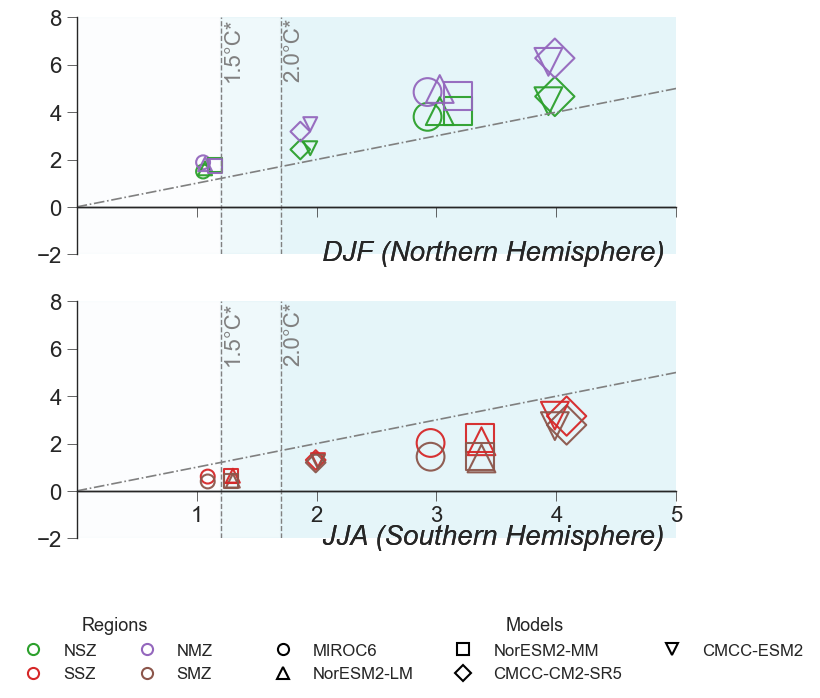

In [27]:
# With Legend

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSTas.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"].isin(["126_Longterm", "585_Longterm"])]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    #'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Longterm': 100,   # Smaller size for 126_Midterm
    '585_Longterm': 400    # Larger size for 585_Midterm
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 7), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "DJF: Northern Hemisphere"
    },
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "JJA: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_°C"]
data_max = max(x_all.max(), y_all.max(), 2.0)

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
    ax.axvspan(1.7, 5.0, alpha=1, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # Get size based on period
            size = period_sizes.get(row["Period"], 40)
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_°C"],
                marker=marker,
                s=size,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95
            )

    x_max = 5
    y_min = -2
    y_max = 8
    xticks = np.arange(1, x_max + 0.01, 1)
    yticks = np.arange(y_min, y_max + 0.01, 2)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    # === REMOVE FRAME - keep only X and Y axes ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Keep baseline at Y=0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

    # Move X-axis and its labels to Y=0
    ax.spines['bottom'].set_position('zero')  # Move X-axis to Y=0
    ax.tick_params(axis='x', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)
    ax.tick_params(axis='y', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)

    # Inline labels at end of lines
    ax.text(1.2 + 0.02, 8, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
    ax.text(1.7 + 0.02, 8, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

    ax.plot([0, x_max], [0, x_max], '-.', color='gray', linewidth=1.2, label="1:1 Reference")
    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1)

    # === ANNOTATIONS FOR SEASONS ===
    axs[0].text(0.98, -0.05, 'DJF (Northern Hemisphere)', transform=axs[0].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')
    axs[1].text(0.98, -0.05, 'JJA (Southern Hemisphere)', transform=axs[1].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')

    ax.grid(False)

# === Create Legend Elements ===
# Region colors legend
region_legend = [
    Line2D([0], [0], marker='o', color='w', label='NSZ',
           markerfacecolor='none', markeredgecolor=region_colors['Subtropics_N'], 
           markersize=8, markeredgewidth=1.5, linestyle='None'),
    Line2D([0], [0], marker='o', color='w', label='SSZ',
           markerfacecolor='none', markeredgecolor=region_colors['Subtropics_S'], 
           markersize=8, markeredgewidth=1.5, linestyle='None'),
    Line2D([0], [0], marker='o', color='w', label='NMZ',
           markerfacecolor='none', markeredgecolor=region_colors['Mid_Latitudes_N'], 
           markersize=8, markeredgewidth=1.5, linestyle='None'),
    Line2D([0], [0], marker='o', color='w', label='SMZ',
           markerfacecolor='none', markeredgecolor=region_colors['Mid_Latitudes_S'], 
           markersize=8, markeredgewidth=1.5, linestyle='None'),
]

# Model markers legend
model_legend = [
    Line2D([0], [0], marker=marker, color='w', label=model,
           markerfacecolor='none', markeredgecolor='black', 
           markersize=8, markeredgewidth=1.5, linestyle='None')
    for model, marker in model_markers.items()
]

# Reference lines legend
reference_legend = [
    Line2D([0], [0], color='gray', linestyle='--', linewidth=1.2, label="IPCC Limit (1.5°C and 2.0°C)"),
    Line2D([0], [0], color='black', linestyle='-', linewidth=1, label="Y=0 Baseline"),
    Line2D([0], [0], color='gray', linestyle='-.', linewidth=1.2, label="1:1 Reference"),
]

# Add legends below the subplots
legend1 = fig.legend(handles=region_legend, loc='lower center', 
                     bbox_to_anchor=(0.15, -0.02), ncol=2, frameon=False, 
                     fontsize=12, title='Regions', title_fontsize=13)
legend2 = fig.legend(handles=model_legend, loc='lower center', 
                     bbox_to_anchor=(0.75, -0.02), ncol=3, frameon=False, 
                     fontsize=12, title='Models', title_fontsize=13)

# Add shared axis labels
#fig.text(0.5, 0.02, 'Global Temperature Change (°C)', 
#         ha='center', fontweight='bold', fontsize=16)
#fig.text(0.01, 0.5, 'Regional Temperature Change (°C)', 
#         va='center', rotation='vertical', fontweight='bold', fontsize=16)

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2, bottom=0.20)  # More space for legends
plt.tight_layout(rect=[0, 0.15, 1, 1])  # Leave space for legends
plt.savefig("Global_vs_Regional_Temp_Winter2.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_vs_Regional_Temp_Winter2.png'")
plt.show()

Figure saved as 'Global_vs_Regional_Temp_Winter2.png'


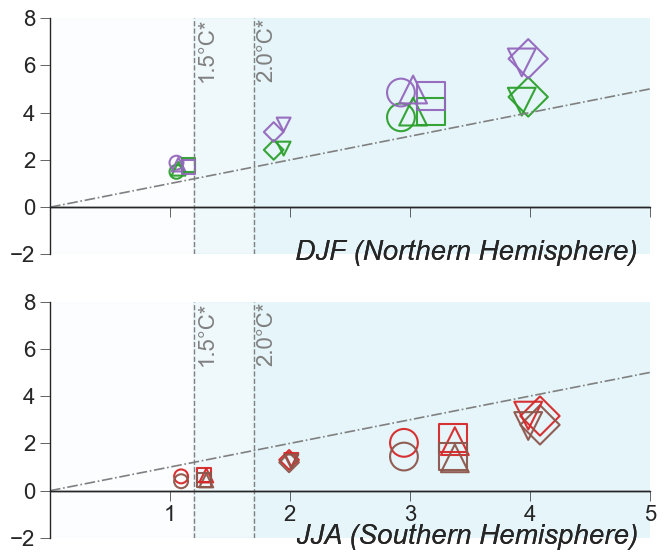

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSTas.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"].isin(["126_Longterm", "585_Longterm"])]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Longterm': 100,   # Smaller size for 126_Midterm
    '585_Longterm': 400    # Larger size for 585_Midterm
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "DJF: Northern Hemisphere"
    },
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "JJA: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_°C"]
data_max = max(x_all.max(), y_all.max(), 2.0)

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
    ax.axvspan(1.7, 5.0, alpha=1, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # Get size based on period
            size = period_sizes.get(row["Period"], 40)
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_°C"],
                marker=marker,
                s=size,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95
            )

    x_max = 5
    y_min = -2
    y_max = 8
    xticks = np.arange(1, x_max + 0.01, 1)
    yticks = np.arange(y_min, y_max + 0.01, 2)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    # === REMOVE FRAME - keep only X and Y axes ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Keep baseline at Y=0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

    # Move X-axis and its labels to Y=0
    ax.spines['bottom'].set_position('zero')  # Move X-axis to Y=0
    ax.tick_params(axis='x', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)
    ax.tick_params(axis='y', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)

    # Inline labels at end of lines
    ax.text(1.2 + 0.02, 8, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
    ax.text(1.7 + 0.02, 8, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

    ax.plot([0, x_max], [0, x_max], '-.', color='gray', linewidth=1.2, label="1:1 Reference")
    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1)

    #ax.set_title(setting["title"], fontsize=16)

    # === ANNOTATIONS FOR SEASONS ===
    axs[0].text(0.98, -0.05, 'DJF (Northern Hemisphere)', transform=axs[0].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')
    axs[1].text(0.98, -0.05, 'JJA (Southern Hemisphere)', transform=axs[1].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')

    ax.grid(False)

# === Shared Legend BELOW plots ===
region_legend = [
    Line2D([0], [0], marker='o', color='w', label=region,
           markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
    for region, color in region_colors.items()
]

reference_legend = [
    Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limit (1.5°C and 2.0°C)"),
    Line2D([0], [0], color='black', linestyle='-', label="Y=0 Baseline"),
]

# Add shared axis labels
#fig.text(0.5, 0.02, 'Global Temperature Change (°C)', 
#         ha='center', fontweight='bold', fontsize=16)
#fig.text(0.01, 0.5, 'Regional Temperature Change (°C)', 
#         va='center', rotation='vertical', fontweight='bold', fontsize=16)

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_vs_Regional_Temp_Winter2.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_vs_Regional_Temp_Winter2.png'")
plt.show()

Figure saved as 'Global_vs_Regional_Temp_Summer2.png'


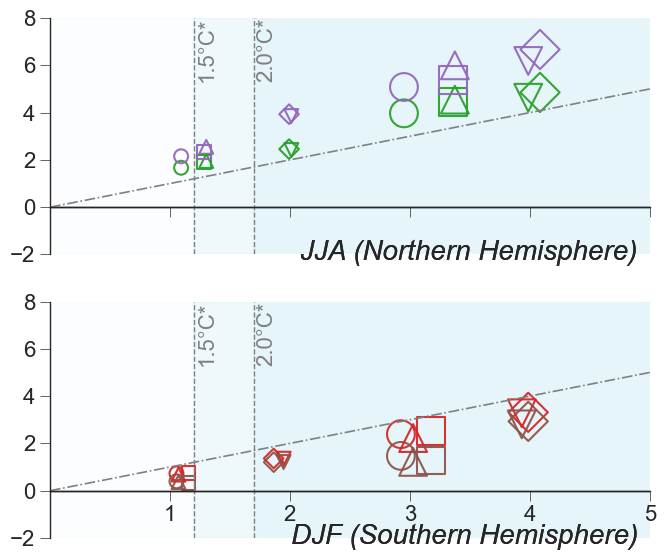

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSTas.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"].isin(["126_Longterm", "585_Longterm"])]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Longterm': 100,   # Smaller size for 126_Midterm
    '585_Longterm': 400    # Larger size for 585_Midterm
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "JJA: Northern Hemisphere"
    },
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "DJF: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_°C"]
data_max = max(x_all.max(), y_all.max(), 2.0)

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
    ax.axvspan(1.7, 5.0, alpha=1, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # Get size based on period
            size = period_sizes.get(row["Period"], 40)
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_°C"],
                marker=marker,
                s=size,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95
            )

    x_max = 5
    y_min = -2
    y_max = 8
    xticks = np.arange(1, x_max + 0.01, 1)
    yticks = np.arange(y_min, y_max + 0.01, 2)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    # === REMOVE FRAME - keep only X and Y axes ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Keep baseline at Y=0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

    # Move X-axis and its labels to Y=0
    ax.spines['bottom'].set_position('zero')  # Move X-axis to Y=0
    ax.tick_params(axis='x', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)
    ax.tick_params(axis='y', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)

    # Inline labels at end of lines
    ax.text(1.2 + 0.02, 8, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
    ax.text(1.7 + 0.02, 8, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

    ax.plot([0, x_max], [0, x_max], '-.', color='gray', linewidth=1.2, label="1:1 Reference")
    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1)

    #ax.set_title(setting["title"], fontsize=16)

    # === ANNOTATIONS FOR SEASONS ===
    axs[0].text(0.98, -0.05, 'JJA (Northern Hemisphere)', transform=axs[0].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')
    axs[1].text(0.98, -0.05, 'DJF (Southern Hemisphere)', transform=axs[1].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')

    ax.grid(False)

# === Shared Legend BELOW plots ===
region_legend = [
    Line2D([0], [0], marker='o', color='w', label=region,
           markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
    for region, color in region_colors.items()
]

reference_legend = [
    Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limit (1.5°C and 2.0°C)"),
    Line2D([0], [0], color='black', linestyle='-', label="Y=0 Baseline"),
]

# Add shared axis labels
#fig.text(0.5, 0.02, 'Global Temperature Change (°C)', 
#         ha='center', fontsize=16)
#fig.text(0.01, 0.5, 'Regional Temperature Change (°C)', 
#         va='center', rotation='vertical', fontweight='bold', fontsize=16)

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_vs_Regional_Temp_Summer2.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_vs_Regional_Temp_Summer2.png'")
plt.show()

# Tas vs Prw

Historical

Figure saved as 'Global_Temp_vs_Prw_Winter0.png'


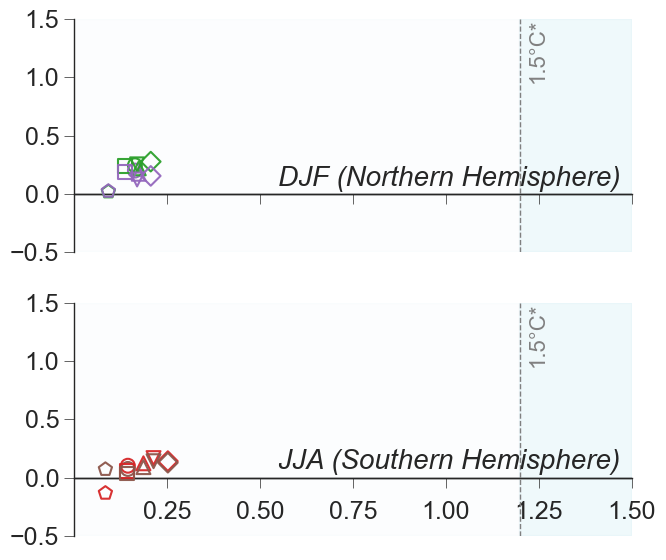

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSPrw.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"] == "Historical"]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "DJF: Northern Hemisphere"
    },
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "JJA: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_mm"]

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.5, alpha=0.6, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_mm"],
                marker=marker,
                s=100,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95,
                zorder=3          # Make sure markers are on top
            )

    x_max = 1.5
    y_min = -0.5
    y_max = 1.5
    xticks = np.arange(0.25, x_max + 0.01, 0.25)
    yticks = np.arange(y_min, y_max + 0.01, 0.5)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=2)
    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1, zorder=2)
    
    ax.text(1.2 + 0.02, 1.5, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')

    # === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Move X-axis to Y=0
    ax.spines['bottom'].set_position(('data', 0))
    
    ax.tick_params(axis='both', which='major', length=7, width=0.5, direction='out', labelsize=18)
    # Move X-axis tick labels to Y=0
    ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0
    ax.grid(False)

# === ANNOTATIONS FOR SEASONS ===
axs[0].text(0.98, 0.26, 'DJF (Northern Hemisphere)', transform=axs[0].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')
axs[1].text(0.98, 0.26, 'JJA (Southern Hemisphere)', transform=axs[1].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_Temp_vs_Prw_Winter0.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_Temp_vs_Prw_Winter0.png'")
plt.show()

Figure saved as 'Global_Temp_vs_Prw_Summer0.png'


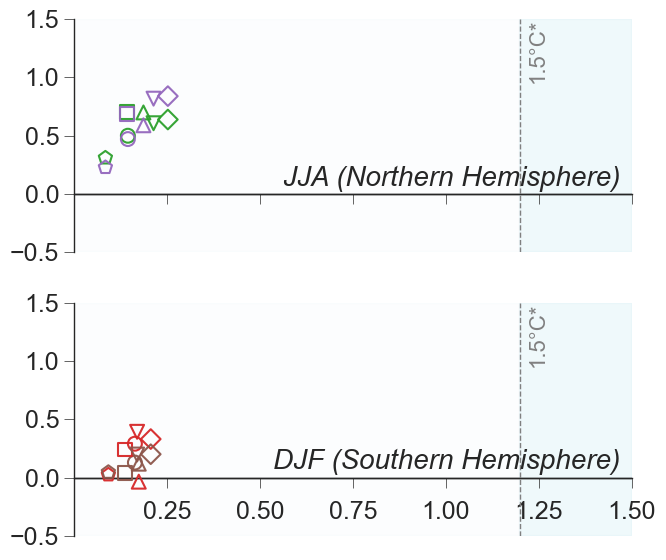

In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSPrw.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"] == "Historical"]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "JJA: Northern Hemisphere"
    },
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "DJF: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_mm"]

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.5, alpha=0.6, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_mm"],
                marker=marker,
                s=100,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95,
                zorder=3          # Make sure markers are on top
            )

    x_max = 1.5
    y_min = -0.5
    y_max = 1.5
    xticks = np.arange(0.25, x_max + 0.01, 0.25)
    yticks = np.arange(y_min, y_max + 0.01, 0.5)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=2)
    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1, zorder=2)
    
    ax.text(1.2 + 0.02, 1.5, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')

    # === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Move X-axis to Y=0
    ax.spines['bottom'].set_position(('data', 0))
    
    ax.tick_params(axis='both', which='major', length=7, width=0.5, direction='out', labelsize=18)
    # Move X-axis tick labels to Y=0
    ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0
    ax.grid(False)

# === ANNOTATIONS FOR SEASONS ===
axs[0].text(0.98, 0.26, 'JJA (Northern Hemisphere)', transform=axs[0].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')
axs[1].text(0.98, 0.26, 'DJF (Southern Hemisphere)', transform=axs[1].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_Temp_vs_Prw_Summer0.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_Temp_vs_Prw_Summer0.png'")
plt.show()

Midterm

Figure saved as 'Global_Temp_vs_Prw_Winter1.png'


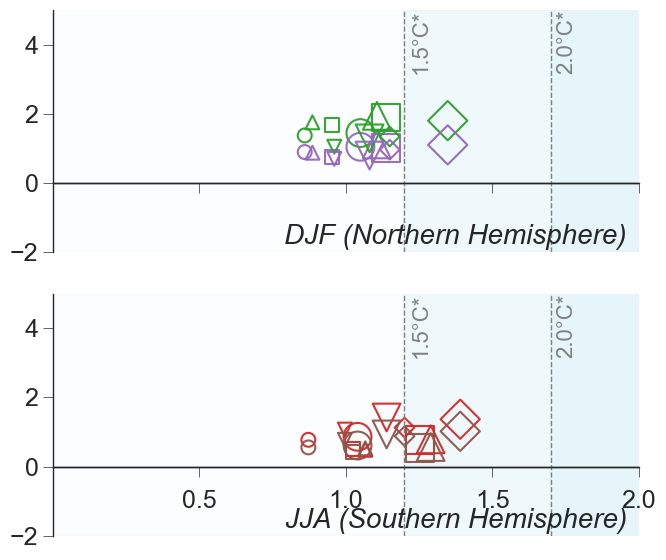

In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSPrw.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"].isin(["126_Midterm", "585_Midterm"])]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Midterm': 100,   # Smaller size for 126_Midterm
    '585_Midterm': 400    # Larger size for 585_Midterm
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "DJF: Northern Hemisphere"
    },
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "JJA: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_mm"]

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)

    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
    ax.axvspan(1.7, 2.0, alpha=1, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # Get size based on period
            size = period_sizes.get(row["Period"], 40)
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_mm"],
                marker=marker,
                s=size,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95
            )

    x_max = 2.0
    y_min = -2
    y_max = 5.0
    xticks = np.arange(0.5, x_max + 0.01, 0.5)
    yticks = np.arange(y_min, y_max + 0.01, 2)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=2)
    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1, zorder=2)
    ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1, zorder=2)
    
    ax.text(1.2 + 0.02, 5, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
    ax.text(1.7 + 0.02, 5, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')


    # === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Move X-axis to Y=0
    ax.spines['bottom'].set_position(('data', 0))
    
    ax.tick_params(axis='both', which='major', length=7, width=0.5, direction='out', labelsize=18)
    # Move X-axis tick labels to Y=0
    ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0
    ax.grid(False)

# === ANNOTATIONS FOR SEASONS ===
axs[0].text(0.98, 0.01, 'DJF (Northern Hemisphere)', transform=axs[0].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')
axs[1].text(0.98, 0.01, 'JJA (Southern Hemisphere)', transform=axs[1].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_Temp_vs_Prw_Winter1.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_Temp_vs_Prw_Winter1.png'")
plt.show()

Figure saved as 'Global_Temp_vs_Prw_Summer1.png'


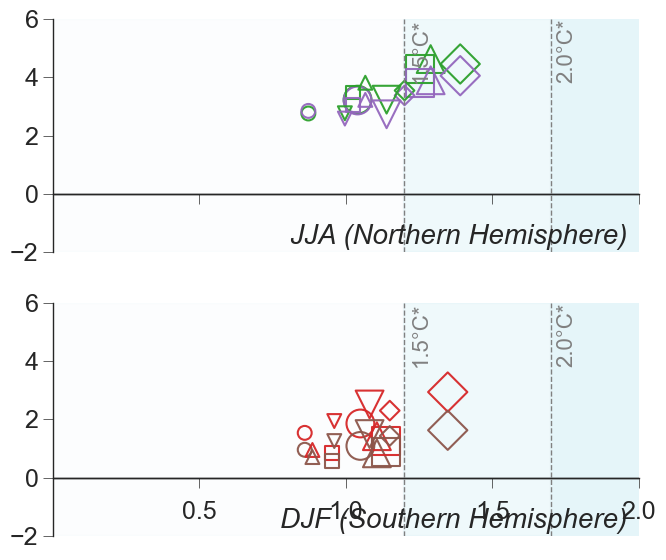

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSPrw.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"].isin(["126_Midterm", "585_Midterm"])]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Midterm': 100,   # Smaller size for 126_Midterm
    '585_Midterm': 400    # Larger size for 585_Midterm
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "JJA: Northern Hemisphere"
    },
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "DJF: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_mm"]

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)

    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
    ax.axvspan(1.7, 2.0, alpha=1.0, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # Get size based on period
            size = period_sizes.get(row["Period"], 40)
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_mm"],
                marker=marker,
                s=size,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95
            )

    x_max = 2.0
    y_min = -2
    y_max = 6.0
    xticks = np.arange(0.5, x_max + 0.01, 0.5)
    yticks = np.arange(y_min, y_max + 0.01, 2)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=2)
    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1, zorder=2)
    ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1, zorder=2)
    
    ax.text(1.2 + 0.02, 6, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
    ax.text(1.7 + 0.02, 6, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')


    # === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Move X-axis to Y=0
    ax.spines['bottom'].set_position(('data', 0))
    
    ax.tick_params(axis='both', which='major', length=7, width=0.5, direction='out', labelsize=18)
    # Move X-axis tick labels to Y=0
    ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0
    ax.grid(False)

# === ANNOTATIONS FOR SEASONS ===
axs[0].text(0.98, 0.01, 'JJA (Northern Hemisphere)', transform=axs[0].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')
axs[1].text(0.98, 0.01, 'DJF (Southern Hemisphere)', transform=axs[1].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_Temp_vs_Prw_Summer1.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_Temp_vs_Prw_Summer1.png'")
plt.show()

Longterm

Figure saved as 'Global_Temp_vs_Prw_Winter2.png'


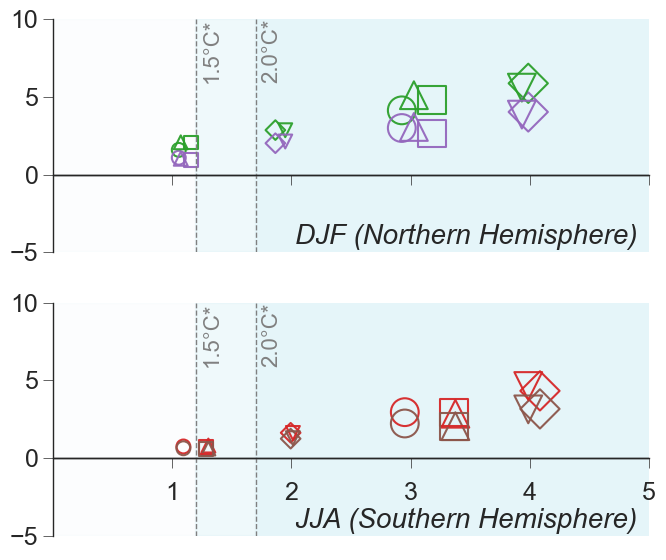

In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSPrw.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"].isin(["126_Longterm", "585_Longterm"])]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Longterm': 100,   # Smaller size for 126_Midterm
    '585_Longterm': 400    # Larger size for 585_Midterm
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "DJF: Northern Hemisphere"
    },
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "JJA: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_mm"]

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)

    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
    ax.axvspan(1.7, 5.0, alpha=1.0, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # Get size based on period
            size = period_sizes.get(row["Period"], 40)
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_mm"],
                marker=marker,
                s=size,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95
            )

    x_max = 5.0
    y_min = -5
    y_max = 10.0
    xticks = np.arange(1, x_max + 0.01, 1)
    yticks = np.arange(y_min, y_max + 0.01, 5)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=2)
    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1, zorder=2)
    ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1, zorder=2)
    
    ax.text(1.2 + 0.05, 10, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
    ax.text(1.7 + 0.05, 10, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')


    # === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Move X-axis to Y=0
    ax.spines['bottom'].set_position(('data', 0))
    
    ax.tick_params(axis='both', which='major', length=7, width=0.5, direction='out', labelsize=18)
    # Move X-axis tick labels to Y=0
    ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0
    ax.grid(False)

# === ANNOTATIONS FOR SEASONS ===
axs[0].text(0.98, 0.01, 'DJF (Northern Hemisphere)', transform=axs[0].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')
axs[1].text(0.98, 0.01, 'JJA (Southern Hemisphere)', transform=axs[1].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_Temp_vs_Prw_Winter2.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_Temp_vs_Prw_Winter2.png'")
plt.show()

Figure saved as 'Global_Temp_vs_Prw_Summer2.png'


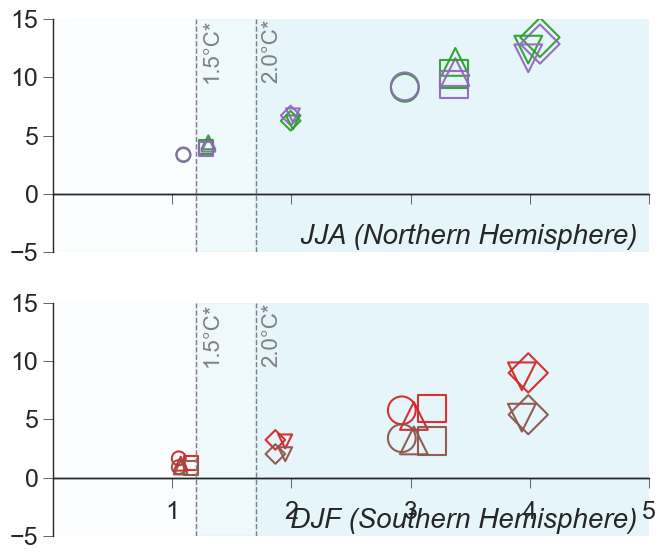

In [58]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSPrw.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"].isin(["126_Longterm", "585_Longterm"])]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Longterm': 100,   # Smaller size for 126_Midterm
    '585_Longterm': 400    # Larger size for 585_Midterm
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "JJA: Northern Hemisphere"
    },
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "DJF: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_mm"]

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)

    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
    ax.axvspan(1.7, 5.0, alpha=1, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # Get size based on period
            size = period_sizes.get(row["Period"], 40)
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_mm"],
                marker=marker,
                s=size,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95
            )

    x_max = 5.0
    y_min = -5
    y_max = 15.0
    xticks = np.arange(1, x_max + 0.01, 1)
    yticks = np.arange(y_min, y_max + 0.01, 5)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=2)
    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1, zorder=2)
    ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1, zorder=2)
    
    ax.text(1.2 + 0.05, 15, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
    ax.text(1.7 + 0.05, 15, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')


    # === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Move X-axis to Y=0
    ax.spines['bottom'].set_position(('data', 0))
    
    ax.tick_params(axis='both', which='major', length=7, width=0.5, direction='out', labelsize=18)
    # Move X-axis tick labels to Y=0
    ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0
    ax.grid(False)

# === ANNOTATIONS FOR SEASONS ===
axs[0].text(0.98, 0.01, 'JJA (Northern Hemisphere)', transform=axs[0].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')
axs[1].text(0.98, 0.01, 'DJF (Southern Hemisphere)', transform=axs[1].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_Temp_vs_Prw_Summer2.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_Temp_vs_Prw_Summer2.png'")
plt.show()

# Tas vs Pr

Historical

Figure saved as 'Global_Temp_vs_Pr_Winter0.png'


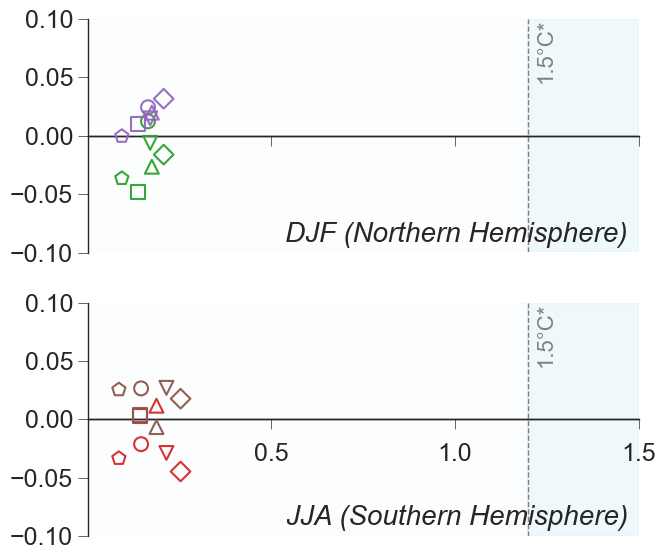

In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSPr.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"] == "Historical"]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "DJF: Northern Hemisphere"
    },
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "JJA: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_mm/day"]

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.5, alpha=0.6, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_mm/day"],
                marker=marker,
                s=100,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95,
                zorder=3          # Make sure markers are on top
            )

    x_max = 1.5
    y_min = -0.1
    y_max = 0.1
    xticks = np.arange(0.5, x_max + 0.01, 0.5)
    yticks = np.arange(y_min, y_max + 0.01, 0.05)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=2)
    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1, zorder=2)
    
    ax.text(1.2 + 0.02, 0.1, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')

    # === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Move X-axis to Y=0
    ax.spines['bottom'].set_position(('data', 0))
    
    ax.tick_params(axis='both', which='major', length=7, width=0.5, direction='out', labelsize=18)
    # Move X-axis tick labels to Y=0
    ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0
    ax.grid(False)

# === ANNOTATIONS FOR SEASONS ===
axs[0].text(0.98, 0.02, 'DJF (Northern Hemisphere)', transform=axs[0].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')
axs[1].text(0.98, 0.02, 'JJA (Southern Hemisphere)', transform=axs[1].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_Temp_vs_Pr_Winter0.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_Temp_vs_Pr_Winter0.png'")
plt.show()

Figure saved as 'Global_Temp_vs_Pr_Summer0.png'


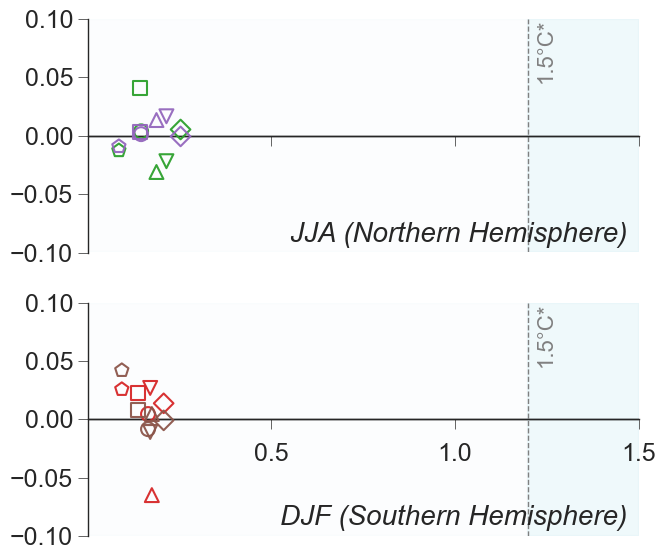

In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSPr.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"] == "Historical"]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "JJA: Northern Hemisphere"
    },
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "DJF: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_mm/day"]

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.5, alpha=0.6, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_mm/day"],
                marker=marker,
                s=100,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95,
                zorder=3          # Make sure markers are on top
            )

    x_max = 1.5
    y_min = -0.1
    y_max = 0.1
    xticks = np.arange(0.5, x_max + 0.01, 0.5)
    yticks = np.arange(y_min, y_max + 0.01, 0.05)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=2)
    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1, zorder=2)
    
    ax.text(1.2 + 0.02, 0.1, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')

    # === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Move X-axis to Y=0
    ax.spines['bottom'].set_position(('data', 0))
    
    ax.tick_params(axis='both', which='major', length=7, width=0.5, direction='out', labelsize=18)
    # Move X-axis tick labels to Y=0
    ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0
    ax.grid(False)

# === ANNOTATIONS FOR SEASONS ===
axs[0].text(0.98, 0.02, 'JJA (Northern Hemisphere)', transform=axs[0].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')
axs[1].text(0.98, 0.02, 'DJF (Southern Hemisphere)', transform=axs[1].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_Temp_vs_Pr_Summer0.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_Temp_vs_Pr_Summer0.png'")
plt.show()

Midterm

Figure saved as 'Global_Temp_vs_Pr_Winter1.png'


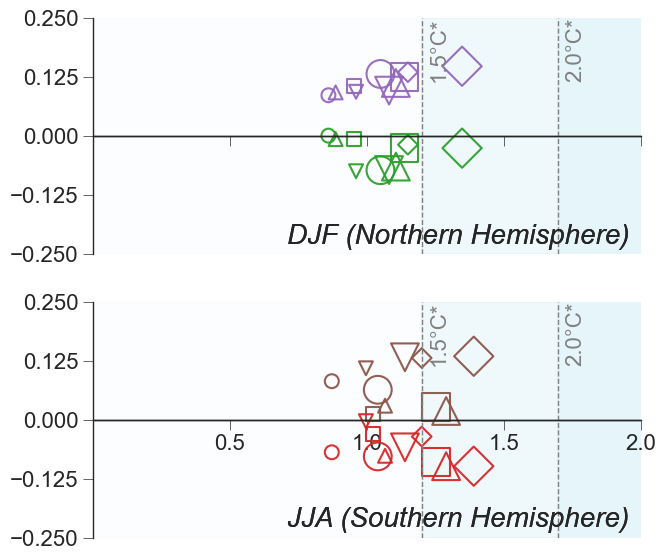

In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSPr.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"].isin(["126_Midterm", "585_Midterm"])]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Midterm': 100,   # Smaller size for 126_Midterm
    '585_Midterm': 400    # Larger size for 585_Midterm
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "DJF: Northern Hemisphere"
    },
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "JJA: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_mm/day"]
data_max = max(x_all.max(), y_all.max(), 2.0)

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
    ax.axvspan(1.7, 2.0, alpha=1.0, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # Get size based on period
            size = period_sizes.get(row["Period"], 40)
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_mm/day"],
                marker=marker,
                s=size,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95
            )

    x_max = 2
    y_min = -0.25
    y_max = 0.25
    xticks = np.arange(0.5, x_max + 0.01, 0.5)
    yticks = np.arange(y_min, y_max + 0.01, 0.125)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    # === REMOVE FRAME - keep only X and Y axes ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Keep baseline at Y=0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

    # Move X-axis and its labels to Y=0
    ax.spines['bottom'].set_position('zero')  # Move X-axis to Y=0
    ax.tick_params(axis='x', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)
    ax.tick_params(axis='y', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)

    # Inline labels at end of lines
    ax.text(1.2 + 0.025, 0.25, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
    ax.text(1.7 + 0.025, 0.25, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1)

    #ax.set_title(setting["title"], fontsize=16)

    # === ANNOTATIONS FOR SEASONS ===
    axs[0].text(0.98, 0.02, 'DJF (Northern Hemisphere)', transform=axs[0].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')
    axs[1].text(0.98, 0.02, 'JJA (Southern Hemisphere)', transform=axs[1].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')

    ax.grid(False)

# === Shared Legend BELOW plots ===
region_legend = [
    Line2D([0], [0], marker='o', color='w', label=region,
           markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
    for region, color in region_colors.items()
]

reference_legend = [
    Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limit (1.5°C and 2.0°C)"),
    Line2D([0], [0], color='black', linestyle='-', label="Y=0 Baseline"),
]

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_Temp_vs_Pr_Winter1.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_Temp_vs_Pr_Winter1.png'")
plt.show()

Figure saved as 'Global_Temp_vs_Pr_Summer1.png'


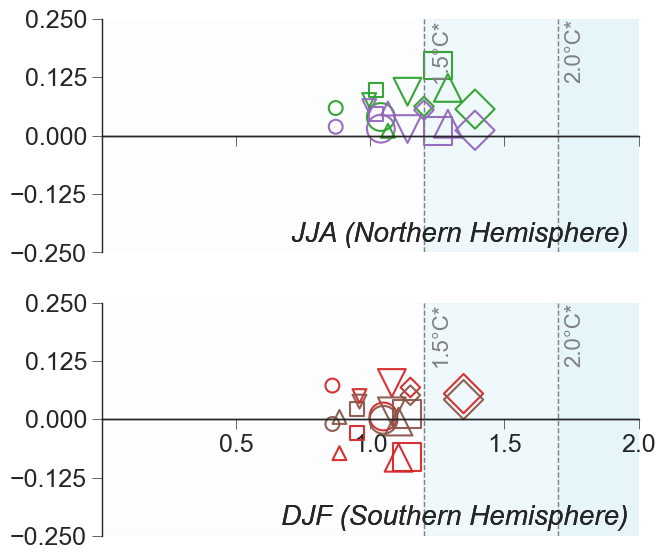

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSPr.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"].isin(["126_Midterm", "585_Midterm"])]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Midterm': 100,   # Smaller size for 126_Midterm
    '585_Midterm': 400    # Larger size for 585_Midterm
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "JJA: Northern Hemisphere"
    },
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "DJF: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_mm/day"]
data_max = max(x_all.max(), y_all.max(), 2.0)

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
    ax.axvspan(1.7, 2.0, alpha=1.0, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # Get size based on period
            size = period_sizes.get(row["Period"], 40)
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_mm/day"],
                marker=marker,
                s=size,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95
            )

    x_max = 2
    y_min = -0.25
    y_max = 0.25
    xticks = np.arange(0.5, x_max + 0.01, 0.5)
    yticks = np.arange(y_min, y_max + 0.01, 0.125)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    # === REMOVE FRAME - keep only X and Y axes ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Keep baseline at Y=0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

    # Move X-axis and its labels to Y=0
    ax.spines['bottom'].set_position('zero')  # Move X-axis to Y=0
    ax.tick_params(axis='x', which='major', length=7, width=0.5, direction='out', 
                   labelsize=18)
    ax.tick_params(axis='y', which='major', length=7, width=0.5, direction='out', 
                   labelsize=18)

    # Inline labels at end of lines
    ax.text(1.2 + 0.025, 0.25, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
    ax.text(1.7 + 0.025, 0.25, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1)

    #ax.set_title(setting["title"], fontsize=16)

    # === ANNOTATIONS FOR SEASONS ===
    axs[0].text(0.98, 0.02, 'JJA (Northern Hemisphere)', transform=axs[0].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')
    axs[1].text(0.98, 0.02, 'DJF (Southern Hemisphere)', transform=axs[1].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')

    ax.grid(False)

# === Shared Legend BELOW plots ===
region_legend = [
    Line2D([0], [0], marker='o', color='w', label=region,
           markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
    for region, color in region_colors.items()
]

reference_legend = [
    Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limit (1.5°C and 2.0°C)"),
    Line2D([0], [0], color='black', linestyle='-', label="Y=0 Baseline"),
]

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_Temp_vs_Pr_Summer1.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_Temp_vs_Pr_Summer1.png'")
plt.show()

Longterm

Figure saved as 'Global_Temp_vs_Pr_Winter2.png'


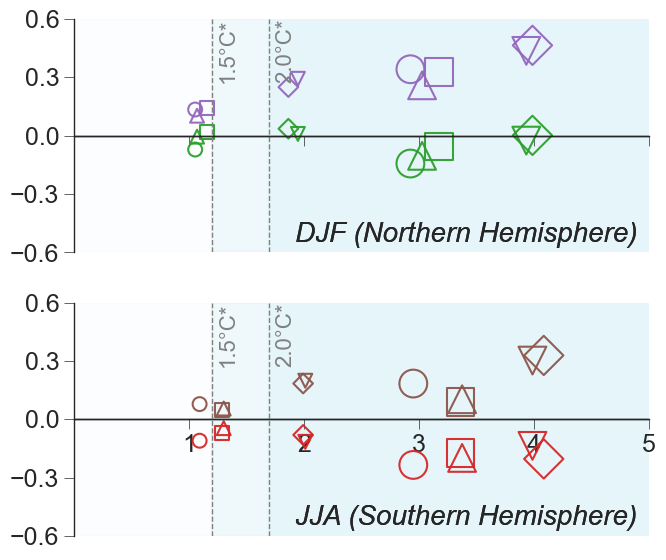

In [63]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSPr.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"].isin(["126_Longterm", "585_Longterm"])]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Longterm': 100,   # Smaller size for 126_Longterm
    '585_Longterm': 400    # Larger size for 585_Longterm
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "DJF: Northern Hemisphere"
    },
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "JJA: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_mm/day"]
data_max = max(x_all.max(), y_all.max(), 2.0)

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
    ax.axvspan(1.7, 5.0, alpha=1.0, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # Get size based on period
            size = period_sizes.get(row["Period"], 40)
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_mm/day"],
                marker=marker,
                s=size,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95
            )

    x_max = 5
    y_min = -0.6
    y_max = 0.6
    xticks = np.arange(1, x_max + 0.01, 1)
    yticks = np.arange(y_min, y_max + 0.01, 0.3)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    # === REMOVE FRAME - keep only X and Y axes ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Keep baseline at Y=0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

    # Move X-axis and its labels to Y=0
    ax.spines['bottom'].set_position('zero')  # Move X-axis to Y=0
    ax.tick_params(axis='x', which='major', length=7, width=0.5, direction='out', 
                   labelsize=18)
    ax.tick_params(axis='y', which='major', length=7, width=0.5, direction='out', 
                   labelsize=18)

    # Inline labels at end of lines
    ax.text(1.2 + 0.05, 0.6, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
    ax.text(1.7 + 0.05, 0.6, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1)

    #ax.set_title(setting["title"], fontsize=16)

    # === ANNOTATIONS FOR SEASONS ===
    axs[0].text(0.98, 0.02, 'DJF (Northern Hemisphere)', transform=axs[0].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')
    axs[1].text(0.98, 0.02, 'JJA (Southern Hemisphere)', transform=axs[1].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')

    ax.grid(False)

# === Shared Legend BELOW plots ===
region_legend = [
    Line2D([0], [0], marker='o', color='w', label=region,
           markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
    for region, color in region_colors.items()
]

reference_legend = [
    Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limit (1.5°C and 2.0°C)"),
    Line2D([0], [0], color='black', linestyle='-', label="Y=0 Baseline"),
]

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_Temp_vs_Pr_Winter2.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_Temp_vs_Pr_Winter2.png'")
plt.show()

Figure saved as 'Global_Temp_vs_Pr_Summer2.png'


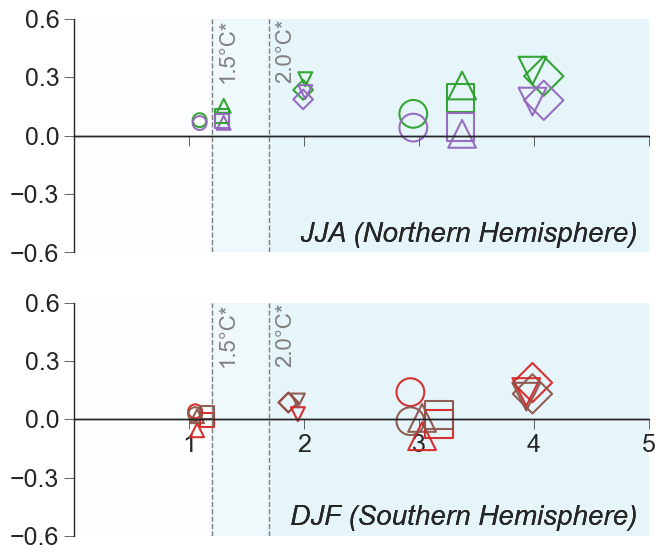

In [64]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSPr.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"].isin(["126_Longterm", "585_Longterm"])]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Longterm': 100,   # Smaller size for 126_Longterm
    '585_Longterm': 400    # Larger size for 585_Longterm
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "JJA: Northern Hemisphere"
    },
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "DJF: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_mm/day"]
data_max = max(x_all.max(), y_all.max(), 2.0)

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
    ax.axvspan(1.7, 5.0, alpha=1.0, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # Get size based on period
            size = period_sizes.get(row["Period"], 40)
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_mm/day"],
                marker=marker,
                s=size,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95
            )

    x_max = 5
    y_min = -0.6
    y_max = 0.6
    xticks = np.arange(1, x_max + 0.01, 1)
    yticks = np.arange(y_min, y_max + 0.01, 0.3)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    # === REMOVE FRAME - keep only X and Y axes ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Keep baseline at Y=0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

    # Move X-axis and its labels to Y=0
    ax.spines['bottom'].set_position('zero')  # Move X-axis to Y=0
    ax.tick_params(axis='x', which='major', length=7, width=0.5, direction='out', 
                   labelsize=18)
    ax.tick_params(axis='y', which='major', length=7, width=0.5, direction='out', 
                   labelsize=18)

    # Inline labels at end of lines
    ax.text(1.2 + 0.05, 0.6, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
    ax.text(1.7 + 0.05, 0.6, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1)

    #ax.set_title(setting["title"], fontsize=16)

    # === ANNOTATIONS FOR SEASONS ===
    axs[0].text(0.98, 0.02, 'JJA (Northern Hemisphere)', transform=axs[0].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')
    axs[1].text(0.98, 0.02, 'DJF (Southern Hemisphere)', transform=axs[1].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')

    ax.grid(False)

# === Shared Legend BELOW plots ===
region_legend = [
    Line2D([0], [0], marker='o', color='w', label=region,
           markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
    for region, color in region_colors.items()
]

reference_legend = [
    Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limit (1.5°C and 2.0°C)"),
    Line2D([0], [0], color='black', linestyle='-', label="Y=0 Baseline"),
]

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_Temp_vs_Pr_Summer2.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_Temp_vs_Pr_Summer2.png'")
plt.show()

# Tas vs E

Historical

Figure saved as 'Global_Temp_vs_E_Winter0.png'


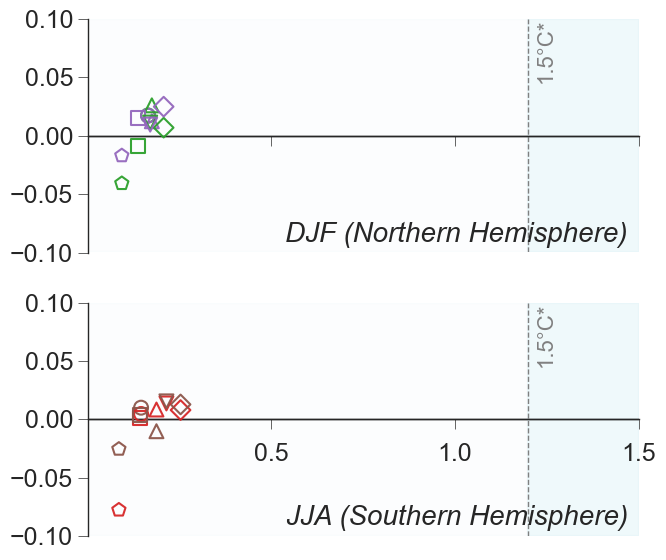

In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSE.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"] == "Historical"]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "DJF: Northern Hemisphere"
    },
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "JJA: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_mm/day"]

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.5, alpha=0.6, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_mm/day"],
                marker=marker,
                s=100,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95,
                zorder=3          # Make sure markers are on top
            )

    x_max = 1.5
    y_min = -0.1
    y_max = 0.1
    xticks = np.arange(0.5, x_max + 0.01, 0.5)
    yticks = np.arange(y_min, y_max + 0.01, 0.05)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=2)
    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1, zorder=2)
    
    ax.text(1.2 + 0.02, 0.1, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')

    # === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Move X-axis to Y=0
    ax.spines['bottom'].set_position(('data', 0))
    
    ax.tick_params(axis='both', which='major', length=7, width=0.5, direction='out', labelsize=18)
    # Move X-axis tick labels to Y=0
    ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0
    ax.grid(False)

# === ANNOTATIONS FOR SEASONS ===
axs[0].text(0.98, 0.02, 'DJF (Northern Hemisphere)', transform=axs[0].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')
axs[1].text(0.98, 0.02, 'JJA (Southern Hemisphere)', transform=axs[1].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_Temp_vs_E_Winter0.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_Temp_vs_E_Winter0.png'")
plt.show()

Figure saved as 'Global_Temp_vs_E_Summer0.png'


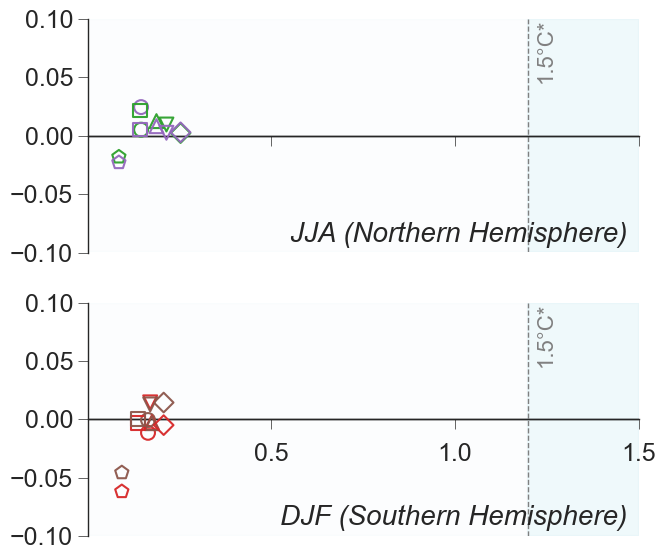

In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSE.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"] == "Historical"]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "JJA: Northern Hemisphere"
    },
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "DJF: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_mm/day"]

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.5, alpha=0.6, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_mm/day"],
                marker=marker,
                s=100,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95,
                zorder=3          # Make sure markers are on top
            )

    x_max = 1.5
    y_min = -0.1
    y_max = 0.1
    xticks = np.arange(0.5, x_max + 0.01, 0.5)
    yticks = np.arange(y_min, y_max + 0.01, 0.05)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=2)
    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1, zorder=2)
    
    ax.text(1.2 + 0.02, 0.1, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')

    # === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Move X-axis to Y=0
    ax.spines['bottom'].set_position(('data', 0))
    
    ax.tick_params(axis='both', which='major', length=7, width=0.5, direction='out', labelsize=18)
    # Move X-axis tick labels to Y=0
    ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0
    ax.grid(False)

# === ANNOTATIONS FOR SEASONS ===
axs[0].text(0.98, 0.02, 'JJA (Northern Hemisphere)', transform=axs[0].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')
axs[1].text(0.98, 0.02, 'DJF (Southern Hemisphere)', transform=axs[1].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_Temp_vs_E_Summer0.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_Temp_vs_E_Summer0.png'")
plt.show()

Midterm

Figure saved as 'Global_Temp_vs_E_Winter1.png'


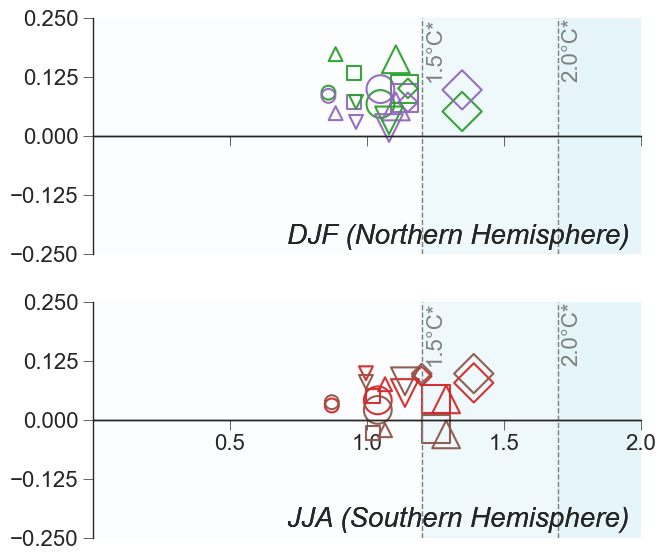

In [72]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSE.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"].isin(["126_Midterm", "585_Midterm"])]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Midterm': 100,   # Smaller size for 126_Midterm
    '585_Midterm': 400    # Larger size for 585_Midterm
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "DJF: Northern Hemisphere"
    },
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "JJA: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_mm/day"]
data_max = max(x_all.max(), y_all.max(), 2.0)

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
    ax.axvspan(1.7, 2.0, alpha=1.0, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # Get size based on period
            size = period_sizes.get(row["Period"], 40)
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_mm/day"],
                marker=marker,
                s=size,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95
            )

    x_max = 2
    y_min = -0.25
    y_max = 0.25
    xticks = np.arange(0.5, x_max + 0.01, 0.5)
    yticks = np.arange(y_min, y_max + 0.01, 0.125)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    # === REMOVE FRAME - keep only X and Y axes ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Keep baseline at Y=0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

    # Move X-axis and its labels to Y=0
    ax.spines['bottom'].set_position('zero')  # Move X-axis to Y=0
    ax.tick_params(axis='x', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)
    ax.tick_params(axis='y', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)

    # Inline labels at end of lines
    ax.text(1.2 + 0.01, 0.25, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
    ax.text(1.7 + 0.01, 0.25, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1)

    #ax.set_title(setting["title"], fontsize=16)

    # === ANNOTATIONS FOR SEASONS ===
    axs[0].text(0.98, 0.02, 'DJF (Northern Hemisphere)', transform=axs[0].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')
    axs[1].text(0.98, 0.02, 'JJA (Southern Hemisphere)', transform=axs[1].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')

    ax.grid(False)

# === Shared Legend BELOW plots ===
region_legend = [
    Line2D([0], [0], marker='o', color='w', label=region,
           markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
    for region, color in region_colors.items()
]

reference_legend = [
    Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limit (1.5°C and 2.0°C)"),
    Line2D([0], [0], color='black', linestyle='-', label="Y=0 Baseline"),
]

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_Temp_vs_E_Winter1.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_Temp_vs_E_Winter1.png'")
plt.show()

Figure saved as 'Global_Temp_vs_E_Summer1.png'


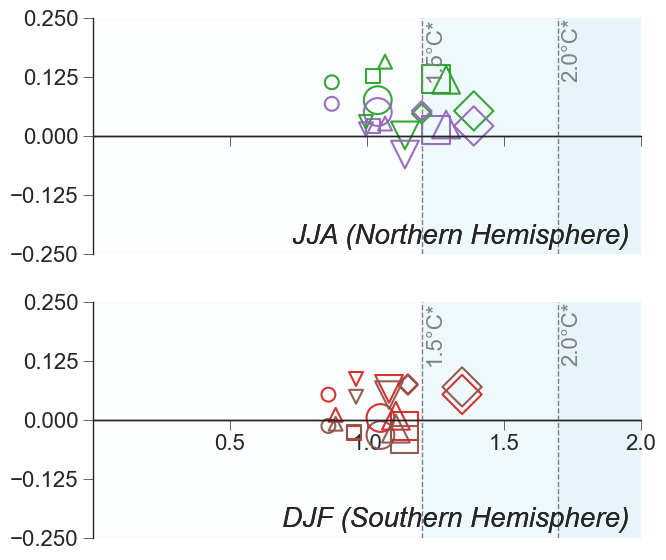

In [77]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSE.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"].isin(["126_Midterm", "585_Midterm"])]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Midterm': 100,   # Smaller size for 126_Midterm
    '585_Midterm': 400    # Larger size for 585_Midterm
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "JJA: Northern Hemisphere"
    },
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "DJF: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_mm/day"]
data_max = max(x_all.max(), y_all.max(), 2.0)

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
    ax.axvspan(1.7, 2.0, alpha=1.0, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # Get size based on period
            size = period_sizes.get(row["Period"], 40)
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_mm/day"],
                marker=marker,
                s=size,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95
            )

    x_max = 2
    y_min = -0.25
    y_max = 0.25
    xticks = np.arange(0.5, x_max + 0.01, 0.5)
    yticks = np.arange(y_min, y_max + 0.01, 0.125)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    # === REMOVE FRAME - keep only X and Y axes ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Keep baseline at Y=0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

    # Move X-axis and its labels to Y=0
    ax.spines['bottom'].set_position('zero')  # Move X-axis to Y=0
    ax.tick_params(axis='x', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)
    ax.tick_params(axis='y', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)

    # Inline labels at end of lines
    ax.text(1.2 + 0.01, 0.25, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
    ax.text(1.7 + 0.01, 0.25, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1)

    #ax.set_title(setting["title"], fontsize=16)

    # === ANNOTATIONS FOR SEASONS ===
    axs[0].text(0.98, 0.02, 'JJA (Northern Hemisphere)', transform=axs[0].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')
    axs[1].text(0.98, 0.02, 'DJF (Southern Hemisphere)', transform=axs[1].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')

    ax.grid(False)

# === Shared Legend BELOW plots ===
region_legend = [
    Line2D([0], [0], marker='o', color='w', label=region,
           markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
    for region, color in region_colors.items()
]

reference_legend = [
    Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limit (1.5°C and 2.0°C)"),
    Line2D([0], [0], color='black', linestyle='-', label="Y=0 Baseline"),
]

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_Temp_vs_E_Summer1.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_Temp_vs_E_Summer1.png'")
plt.show()

Longterm

Figure saved as 'Global_Temp_vs_E_Winter2.png'


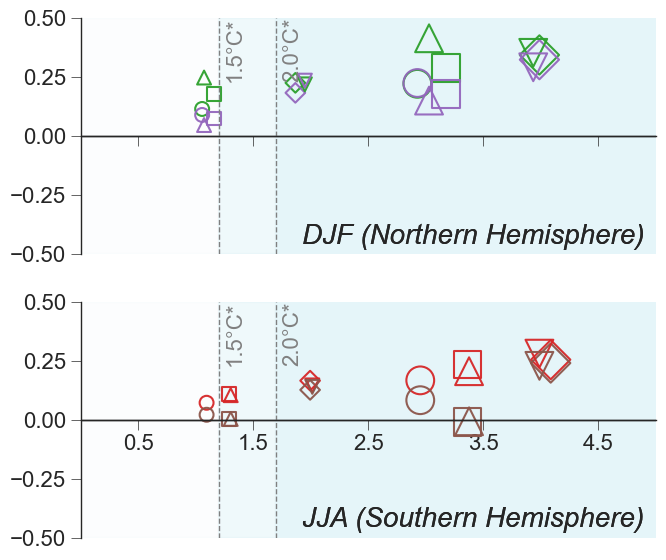

In [79]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSE.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"].isin(["126_Longterm", "585_Longterm"])]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Longterm': 100,   # Smaller size for 126_Midterm
    '585_Longterm': 400    # Larger size for 585_Midterm
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "DJF: Northern Hemisphere"
    },
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "JJA: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_mm/day"]
data_max = max(x_all.max(), y_all.max(), 2.0)

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
    ax.axvspan(1.7, 5.0, alpha=1.0, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # Get size based on period
            size = period_sizes.get(row["Period"], 40)
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_mm/day"],
                marker=marker,
                s=size,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95
            )

    x_max = 5
    y_min = -0.5
    y_max = 0.5
    xticks = np.arange(0.5, x_max + 0.01, 1)
    yticks = np.arange(y_min, y_max + 0.01, 0.25)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    # === REMOVE FRAME - keep only X and Y axes ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Keep baseline at Y=0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

    # Move X-axis and its labels to Y=0
    ax.spines['bottom'].set_position('zero')  # Move X-axis to Y=0
    ax.tick_params(axis='x', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)
    ax.tick_params(axis='y', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)

    # Inline labels at end of lines
    ax.text(1.2 + 0.05, 0.5, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
    ax.text(1.7 + 0.05, 0.5, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1)

    #ax.set_title(setting["title"], fontsize=16)

    # === ANNOTATIONS FOR SEASONS ===
    axs[0].text(0.98, 0.02, 'DJF (Northern Hemisphere)', transform=axs[0].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')
    axs[1].text(0.98, 0.02, 'JJA (Southern Hemisphere)', transform=axs[1].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')

    ax.grid(False)

# === Shared Legend BELOW plots ===
region_legend = [
    Line2D([0], [0], marker='o', color='w', label=region,
           markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
    for region, color in region_colors.items()
]

reference_legend = [
    Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limit (1.5°C and 2.0°C)"),
    Line2D([0], [0], color='black', linestyle='-', label="Y=0 Baseline"),
]

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_Temp_vs_E_Winter2.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_Temp_vs_E_Winter2.png'")
plt.show()

Figure saved as 'Global_Temp_vs_E_Summer2.png'


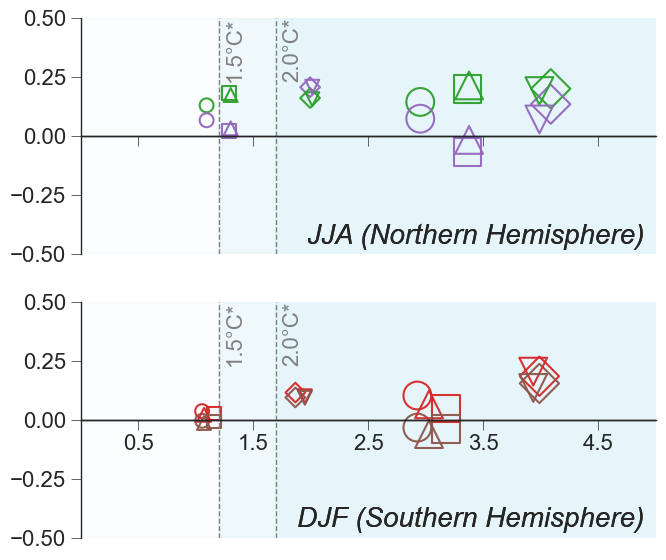

In [80]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSE.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"].isin(["126_Longterm", "585_Longterm"])]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Longterm': 100,   # Smaller size for 126_Midterm
    '585_Longterm': 400    # Larger size for 585_Midterm
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "JJA: Northern Hemisphere"
    },
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "DJF: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_mm/day"]
data_max = max(x_all.max(), y_all.max(), 2.0)

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
    ax.axvspan(1.7, 5.0, alpha=1.0, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # Get size based on period
            size = period_sizes.get(row["Period"], 40)
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_mm/day"],
                marker=marker,
                s=size,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95
            )

    x_max = 5
    y_min = -0.5
    y_max = 0.5
    xticks = np.arange(0.5, x_max + 0.01, 1)
    yticks = np.arange(y_min, y_max + 0.01, 0.25)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    # === REMOVE FRAME - keep only X and Y axes ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Keep baseline at Y=0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

    # Move X-axis and its labels to Y=0
    ax.spines['bottom'].set_position('zero')  # Move X-axis to Y=0
    ax.tick_params(axis='x', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)
    ax.tick_params(axis='y', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)

    # Inline labels at end of lines
    ax.text(1.2 + 0.05, 0.5, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
    ax.text(1.7 + 0.05, 0.5, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1)

    #ax.set_title(setting["title"], fontsize=16)

    # === ANNOTATIONS FOR SEASONS ===
    axs[0].text(0.98, 0.02, 'JJA (Northern Hemisphere)', transform=axs[0].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')
    axs[1].text(0.98, 0.02, 'DJF (Southern Hemisphere)', transform=axs[1].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')

    ax.grid(False)

# === Shared Legend BELOW plots ===
region_legend = [
    Line2D([0], [0], marker='o', color='w', label=region,
           markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
    for region, color in region_colors.items()
]

reference_legend = [
    Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limit (1.5°C and 2.0°C)"),
    Line2D([0], [0], color='black', linestyle='-', label="Y=0 Baseline"),
]

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_Temp_vs_E_Summer2.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_Temp_vs_E_Summer2.png'")
plt.show()

# Tas vs SM

Historical

Figure saved as 'Global_Temp_vs_SM_Winter0.png'


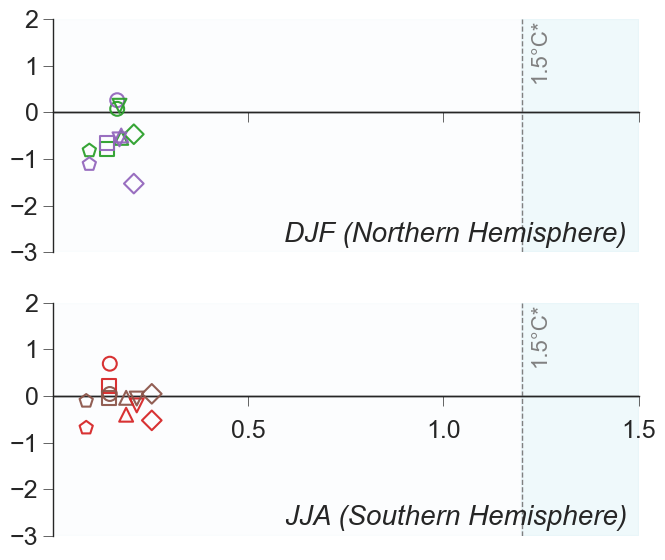

In [96]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSSM.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"] == "Historical"]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SCALE y-variable ===
df["Regional_change_m3/m3"] = df["Regional_change_m3/m3"] * 1000

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "DJF: Northern Hemisphere"
    },
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "JJA: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_m3/m3"]

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.5, alpha=0.6, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_m3/m3"],
                marker=marker,
                s=100,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95,
                zorder=3          # Make sure markers are on top
            )

    x_max = 1.5
    y_min = -3
    y_max = 2
    xticks = np.arange(0.5, x_max + 0.01, 0.5)
    yticks = np.arange(y_min, y_max + 0.01, 1)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=2)
    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1, zorder=2)
    
    ax.text(1.2 + 0.02, 2, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')

    # === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Move X-axis to Y=0
    ax.spines['bottom'].set_position(('data', 0))
    
    ax.tick_params(axis='both', which='major', length=7, width=0.5, direction='out', labelsize=18)
    # Move X-axis tick labels to Y=0
    ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0
    ax.grid(False)

# === ANNOTATIONS FOR SEASONS ===
axs[0].text(0.98, 0.02, 'DJF (Northern Hemisphere)', transform=axs[0].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')
axs[1].text(0.98, 0.02, 'JJA (Southern Hemisphere)', transform=axs[1].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_Temp_vs_SM_Winter0.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_Temp_vs_SM_Winter0.png'")
plt.show()

Figure saved as 'Global_Temp_vs_SM_Summer0.png'


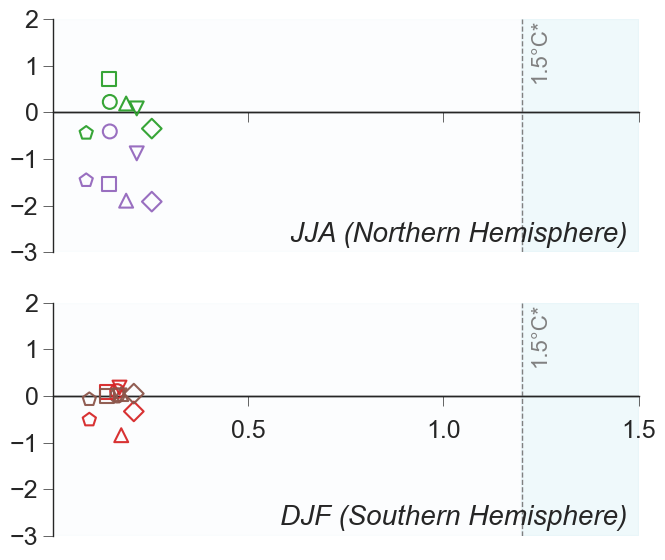

In [95]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSSM.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"] == "Historical"]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SCALE y-variable ===
df["Regional_change_m3/m3"] = df["Regional_change_m3/m3"] * 1000

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "JJA: Northern Hemisphere"
    },
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "DJF: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_m3/m3"]

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.5, alpha=0.6, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_m3/m3"],
                marker=marker,
                s=100,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95,
                zorder=3          # Make sure markers are on top
            )

    x_max = 1.5
    y_min = -3
    y_max = 2
    xticks = np.arange(0.5, x_max + 0.01, 0.5)
    yticks = np.arange(y_min, y_max + 0.01, 1)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=2)
    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1, zorder=2)
    
    ax.text(1.2 + 0.02, 2, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')

    # === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Move X-axis to Y=0
    ax.spines['bottom'].set_position(('data', 0))
    
    ax.tick_params(axis='both', which='major', length=7, width=0.5, direction='out', labelsize=18)
    # Move X-axis tick labels to Y=0
    ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0
    ax.grid(False)

# === ANNOTATIONS FOR SEASONS ===
axs[0].text(0.98, 0.02, 'JJA (Northern Hemisphere)', transform=axs[0].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')
axs[1].text(0.98, 0.02, 'DJF (Southern Hemisphere)', transform=axs[1].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_Temp_vs_SM_Summer0.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_Temp_vs_SM_Summer0.png'")
plt.show()

Midterm

Figure saved as 'Global_Temp_vs_SM_Winter1.png'


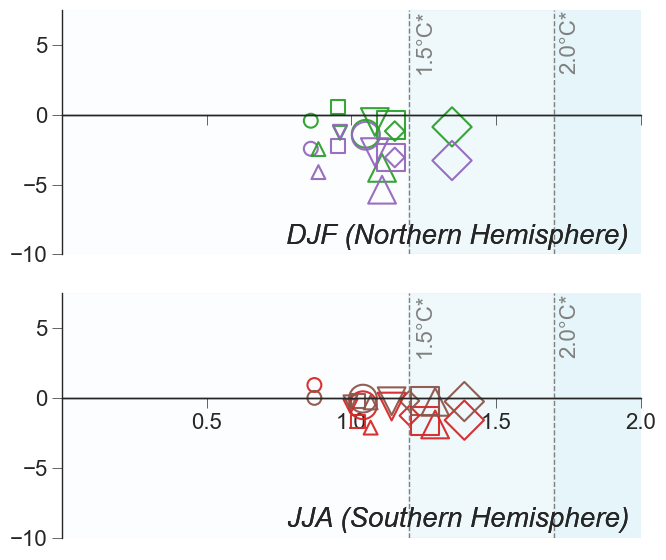

In [98]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSSM.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"].isin(["126_Midterm", "585_Midterm"])]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Midterm': 100,   # Smaller size for 126_Midterm
    '585_Midterm': 400    # Larger size for 585_Midterm
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SCALE y-variable ===
df["Regional_change_m3/m3"] = df["Regional_change_m3/m3"] * 1000

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "DJF: Northern Hemisphere"
    },
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "JJA: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_m3/m3"]
data_max = max(x_all.max(), y_all.max(), 2.0)

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
    ax.axvspan(1.7, 2.0, alpha=1.0, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # Get size based on period
            size = period_sizes.get(row["Period"], 40)
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_m3/m3"],
                marker=marker,
                s=size,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95
            )

    x_max = 2
    y_min = -10
    y_max = 7.5
    xticks = np.arange(0.5, x_max + 0.01, 0.5)
    yticks = np.arange(y_min, y_max + 0.01, 5)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    # === REMOVE FRAME - keep only X and Y axes ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Keep baseline at Y=0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

    # Move X-axis and its labels to Y=0
    ax.spines['bottom'].set_position('zero')  # Move X-axis to Y=0
    ax.tick_params(axis='x', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)
    ax.tick_params(axis='y', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)

    # Inline labels at end of lines
    ax.text(1.2 + 0.02, 7.5, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
    ax.text(1.7 + 0.02, 7.5, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1)

    #ax.set_title(setting["title"], fontsize=16)

    # === ANNOTATIONS FOR SEASONS ===
    axs[0].text(0.98, 0.02, 'DJF (Northern Hemisphere)', transform=axs[0].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')
    axs[1].text(0.98, 0.02, 'JJA (Southern Hemisphere)', transform=axs[1].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')

    ax.grid(False)

# === Shared Legend BELOW plots ===
region_legend = [
    Line2D([0], [0], marker='o', color='w', label=region,
           markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
    for region, color in region_colors.items()
]

reference_legend = [
    Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limit (1.5°C and 2.0°C)"),
    Line2D([0], [0], color='black', linestyle='-', label="Y=0 Baseline"),
]

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_Temp_vs_SM_Winter1.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_Temp_vs_SM_Winter1.png'")
plt.show()

Figure saved as 'Global_Temp_vs_SM_Summer1.png'


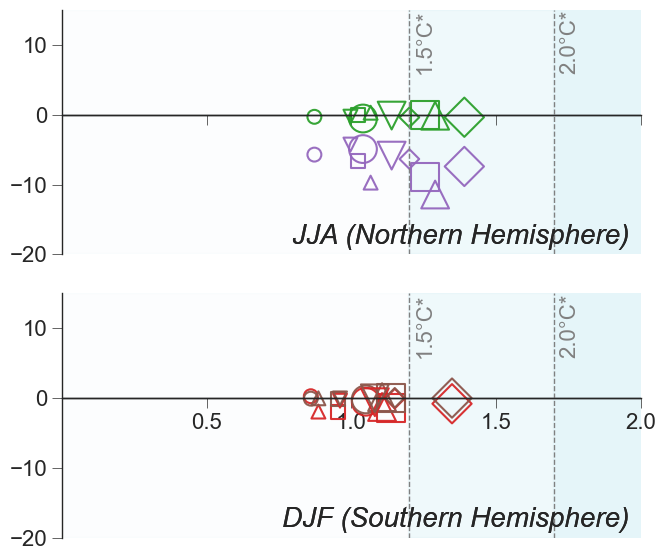

In [103]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSSM.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"].isin(["126_Midterm", "585_Midterm"])]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Midterm': 100,   # Smaller size for 126_Midterm
    '585_Midterm': 400    # Larger size for 585_Midterm
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SCALE y-variable ===
df["Regional_change_m3/m3"] = df["Regional_change_m3/m3"] * 1000

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "JJA: Northern Hemisphere"
    },
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "DJF: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_m3/m3"]
data_max = max(x_all.max(), y_all.max(), 2.0)

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
    ax.axvspan(1.7, 2.0, alpha=1.0, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # Get size based on period
            size = period_sizes.get(row["Period"], 40)
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_m3/m3"],
                marker=marker,
                s=size,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95
            )

    x_max = 2
    y_min = -20
    y_max = 15
    xticks = np.arange(0.5, x_max + 0.01, 0.5)
    yticks = np.arange(y_min, y_max + 0.01, 10)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    # === REMOVE FRAME - keep only X and Y axes ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Keep baseline at Y=0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

    # Move X-axis and its labels to Y=0
    ax.spines['bottom'].set_position('zero')  # Move X-axis to Y=0
    ax.tick_params(axis='x', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)
    ax.tick_params(axis='y', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)

    # Inline labels at end of lines
    ax.text(1.2 + 0.02, 15, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
    ax.text(1.7 + 0.02, 15, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1)

    #ax.set_title(setting["title"], fontsize=16)

    # === ANNOTATIONS FOR SEASONS ===
    axs[0].text(0.98, 0.02, 'JJA (Northern Hemisphere)', transform=axs[0].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')
    axs[1].text(0.98, 0.02, 'DJF (Southern Hemisphere)', transform=axs[1].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')

    ax.grid(False)

# === Shared Legend BELOW plots ===
region_legend = [
    Line2D([0], [0], marker='o', color='w', label=region,
           markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
    for region, color in region_colors.items()
]

reference_legend = [
    Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limit (1.5°C and 2.0°C)"),
    Line2D([0], [0], color='black', linestyle='-', label="Y=0 Baseline"),
]

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_Temp_vs_SM_Summer1.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_Temp_vs_SM_Summer1.png'")
plt.show()

Longterm

Figure saved as 'Global_Temp_vs_SM_Winter2.png'


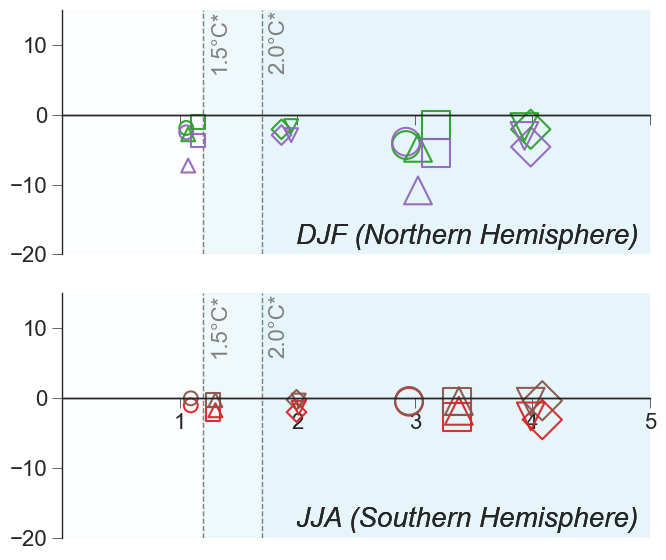

In [104]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSSM.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"].isin(["126_Longterm", "585_Longterm"])]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Longterm': 100,   # Smaller size for 126_Midterm
    '585_Longterm': 400    # Larger size for 585_Midterm
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SCALE y-variable ===
df["Regional_change_m3/m3"] = df["Regional_change_m3/m3"] * 1000

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "DJF: Northern Hemisphere"
    },
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "JJA: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_m3/m3"]
data_max = max(x_all.max(), y_all.max(), 2.0)

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
    ax.axvspan(1.7, 5.0, alpha=1.0, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # Get size based on period
            size = period_sizes.get(row["Period"], 40)
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_m3/m3"],
                marker=marker,
                s=size,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95
            )

    x_max = 5
    y_min = -20
    y_max = 15
    xticks = np.arange(1, x_max + 0.01, 1)
    yticks = np.arange(y_min, y_max + 0.01, 10)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    # === REMOVE FRAME - keep only X and Y axes ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Keep baseline at Y=0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

    # Move X-axis and its labels to Y=0
    ax.spines['bottom'].set_position('zero')  # Move X-axis to Y=0
    ax.tick_params(axis='x', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)
    ax.tick_params(axis='y', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)

    # Inline labels at end of lines
    ax.text(1.2 + 0.05, 15, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
    ax.text(1.7 + 0.05, 15, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1)

    #ax.set_title(setting["title"], fontsize=16)

    # === ANNOTATIONS FOR SEASONS ===
    axs[0].text(0.98, 0.02, 'DJF (Northern Hemisphere)', transform=axs[0].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')
    axs[1].text(0.98, 0.02, 'JJA (Southern Hemisphere)', transform=axs[1].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')

    ax.grid(False)

# === Shared Legend BELOW plots ===
region_legend = [
    Line2D([0], [0], marker='o', color='w', label=region,
           markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
    for region, color in region_colors.items()
]

reference_legend = [
    Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limit (1.5°C and 2.0°C)"),
    Line2D([0], [0], color='black', linestyle='-', label="Y=0 Baseline"),
]

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_Temp_vs_SM_Winter2.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_Temp_vs_SM_Winter2.png'")
plt.show()

Figure saved as 'Global_Temp_vs_SM_Summer2.png'


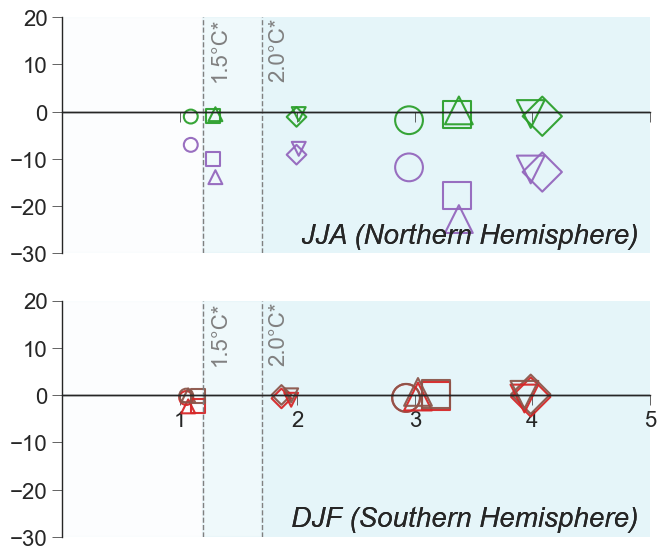

In [101]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSSM.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"].isin(["126_Longterm", "585_Longterm"])]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Longterm': 100,   # Smaller size for 126_Midterm
    '585_Longterm': 400    # Larger size for 585_Midterm
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SCALE y-variable ===
df["Regional_change_m3/m3"] = df["Regional_change_m3/m3"] * 1000

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "JJA: Northern Hemisphere"
    },
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "DJF: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_m3/m3"]
data_max = max(x_all.max(), y_all.max(), 2.0)

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
    ax.axvspan(1.7, 5.0, alpha=1.0, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # Get size based on period
            size = period_sizes.get(row["Period"], 40)
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_m3/m3"],
                marker=marker,
                s=size,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95
            )

    x_max = 5
    y_min = -30
    y_max = 20
    xticks = np.arange(1, x_max + 0.01, 1)
    yticks = np.arange(y_min, y_max + 0.01, 10)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    # === REMOVE FRAME - keep only X and Y axes ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Keep baseline at Y=0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

    # Move X-axis and its labels to Y=0
    ax.spines['bottom'].set_position('zero')  # Move X-axis to Y=0
    ax.tick_params(axis='x', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)
    ax.tick_params(axis='y', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)

    # Inline labels at end of lines
    ax.text(1.2 + 0.05, 20, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
    ax.text(1.7 + 0.05, 20, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1)

    #ax.set_title(setting["title"], fontsize=16)

    # === ANNOTATIONS FOR SEASONS ===
    axs[0].text(0.98, 0.02, 'JJA (Northern Hemisphere)', transform=axs[0].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')
    axs[1].text(0.98, 0.02, 'DJF (Southern Hemisphere)', transform=axs[1].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')

    ax.grid(False)

# === Shared Legend BELOW plots ===
region_legend = [
    Line2D([0], [0], marker='o', color='w', label=region,
           markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
    for region, color in region_colors.items()
]

reference_legend = [
    Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limit (1.5°C and 2.0°C)"),
    Line2D([0], [0], color='black', linestyle='-', label="Y=0 Baseline"),
]

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_Temp_vs_SM_Summer2.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_Temp_vs_SM_Summer2.png'")
plt.show()

# Tas vs q

Historical

Figure saved as 'Global_Temp_vs_q_Winter0.png'


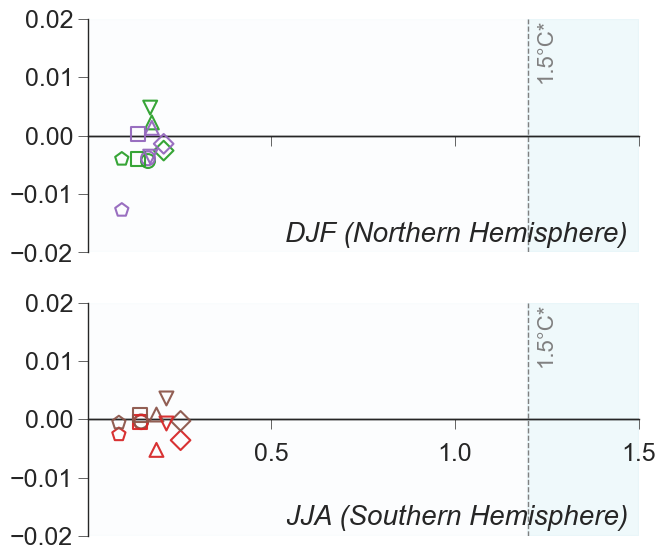

In [111]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSRunoff.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"] == "Historical"]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "DJF: Northern Hemisphere"
    },
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "JJA: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_mm/day"]

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.5, alpha=0.6, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_mm/day"],
                marker=marker,
                s=100,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95,
                zorder=3          # Make sure markers are on top
            )

    x_max = 1.5
    y_min = -0.02
    y_max = 0.02
    xticks = np.arange(0.5, x_max + 0.01, 0.5)
    yticks = np.arange(y_min, y_max + 0.01, 0.01)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=2)
    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1, zorder=2)
    
    ax.text(1.2 + 0.02, 0.02, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')

    # === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Move X-axis to Y=0
    ax.spines['bottom'].set_position(('data', 0))
    
    ax.tick_params(axis='both', which='major', length=7, width=0.5, direction='out', labelsize=18)
    # Move X-axis tick labels to Y=0
    ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0
    ax.grid(False)

# === ANNOTATIONS FOR SEASONS ===
axs[0].text(0.98, 0.02, 'DJF (Northern Hemisphere)', transform=axs[0].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')
axs[1].text(0.98, 0.02, 'JJA (Southern Hemisphere)', transform=axs[1].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_Temp_vs_q_Winter0.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_Temp_vs_q_Winter0.png'")
plt.show()

Figure saved as 'Global_Temp_vs_q_Summer0.png'


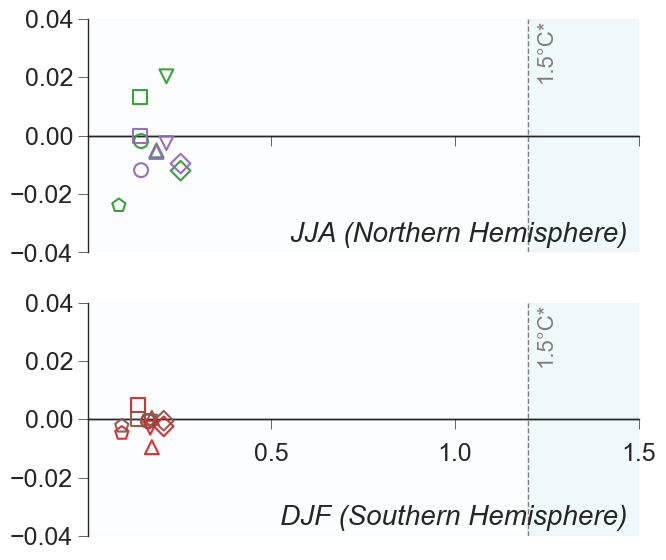

In [120]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSRunoff.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"] == "Historical"]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "JJA: Northern Hemisphere"
    },
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "DJF: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_mm/day"]

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.5, alpha=0.6, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_mm/day"],
                marker=marker,
                s=100,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95,
                zorder=3          # Make sure markers are on top
            )

    x_max = 1.5
    y_min = -0.04
    y_max = 0.04
    xticks = np.arange(0.5, x_max + 0.01, 0.5)
    yticks = np.arange(y_min, y_max + 0.01, 0.02)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=2)
    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1, zorder=2)
    
    ax.text(1.2 + 0.02, 0.04, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')

    # === REMOVE SPINES (BORDER LINES) - KEEP ONLY X AND Y AXES ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Move X-axis to Y=0
    ax.spines['bottom'].set_position(('data', 0))
    
    ax.tick_params(axis='both', which='major', length=7, width=0.5, direction='out', labelsize=18)
    # Move X-axis tick labels to Y=0
    ax.tick_params(axis='x', which='major', pad=10)  # Add some padding below Y=0
    ax.grid(False)

# === ANNOTATIONS FOR SEASONS ===
axs[0].text(0.98, 0.02, 'JJA (Northern Hemisphere)', transform=axs[0].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')
axs[1].text(0.98, 0.02, 'DJF (Southern Hemisphere)', transform=axs[1].transAxes,
       fontsize=20, ha='right', va='bottom', style='italic')

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_Temp_vs_q_Summer0.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_Temp_vs_q_Summer0.png'")
plt.show()

Midterm

Figure saved as 'Global_Temp_vs_q_Winter1.png'


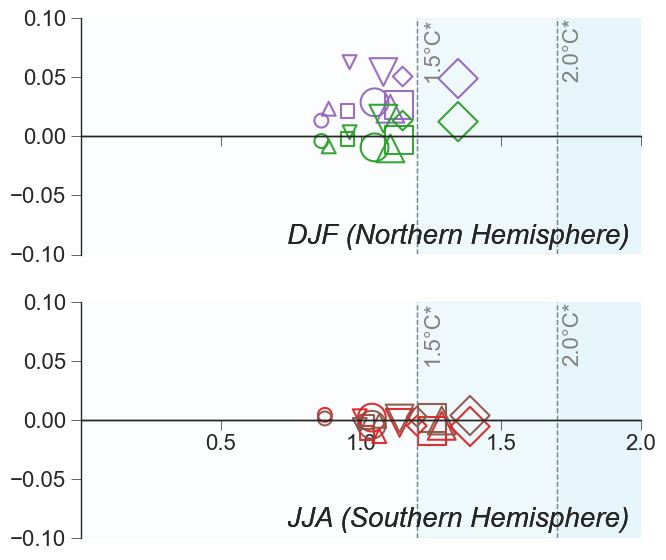

In [113]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSRunoff.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"].isin(["126_Midterm", "585_Midterm"])]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Midterm': 100,   # Smaller size for 126_Midterm
    '585_Midterm': 400    # Larger size for 585_Midterm
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "DJF: Northern Hemisphere"
    },
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "JJA: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_mm/day"]
data_max = max(x_all.max(), y_all.max(), 2.0)

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
    ax.axvspan(1.7, 2.0, alpha=1.0, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # Get size based on period
            size = period_sizes.get(row["Period"], 40)
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_mm/day"],
                marker=marker,
                s=size,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95
            )

    x_max = 2
    y_min = -0.1
    y_max = 0.1
    xticks = np.arange(0.5, x_max + 0.01, 0.5)
    yticks = np.arange(y_min, y_max + 0.01, 0.05)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    # === REMOVE FRAME - keep only X and Y axes ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Keep baseline at Y=0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

    # Move X-axis and its labels to Y=0
    ax.spines['bottom'].set_position('zero')  # Move X-axis to Y=0
    ax.tick_params(axis='x', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)
    ax.tick_params(axis='y', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)

    # Inline labels at end of lines
    ax.text(1.2 + 0.02, 0.1, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
    ax.text(1.7 + 0.02, 0.1, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1)

    #ax.set_title(setting["title"], fontsize=16)

    # === ANNOTATIONS FOR SEASONS ===
    axs[0].text(0.98, 0.02, 'DJF (Northern Hemisphere)', transform=axs[0].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')
    axs[1].text(0.98, 0.02, 'JJA (Southern Hemisphere)', transform=axs[1].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')

    ax.grid(False)

# === Shared Legend BELOW plots ===
region_legend = [
    Line2D([0], [0], marker='o', color='w', label=region,
           markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
    for region, color in region_colors.items()
]

reference_legend = [
    Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limit (1.5°C and 2.0°C)"),
    Line2D([0], [0], color='black', linestyle='-', label="Y=0 Baseline"),
]

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_Temp_vs_q_Winter1.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_Temp_vs_q_Winter1.png'")
plt.show()

Figure saved as 'Global_Temp_vs_q_Summer1.png'


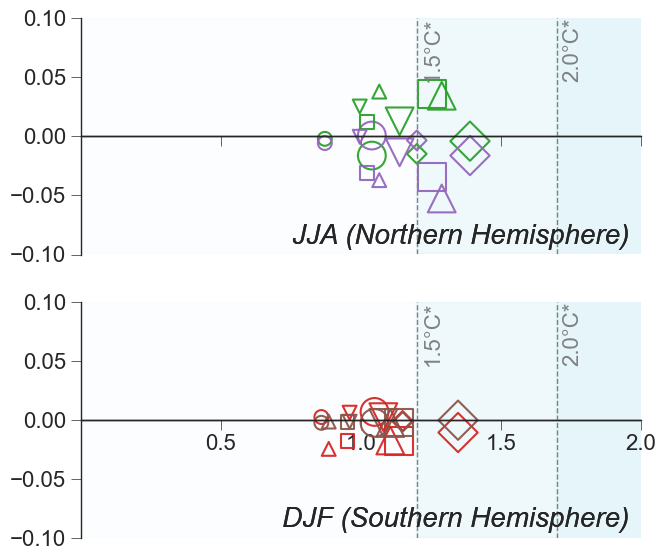

In [114]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSRunoff.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"].isin(["126_Midterm", "585_Midterm"])]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Midterm': 100,   # Smaller size for 126_Midterm
    '585_Midterm': 400    # Larger size for 585_Midterm
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "JJA: Northern Hemisphere"
    },
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "DJF: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_mm/day"]
data_max = max(x_all.max(), y_all.max(), 2.0)

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
    ax.axvspan(1.7, 2.0, alpha=1.0, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # Get size based on period
            size = period_sizes.get(row["Period"], 40)
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_mm/day"],
                marker=marker,
                s=size,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95
            )

    x_max = 2
    y_min = -0.1
    y_max = 0.1
    xticks = np.arange(0.5, x_max + 0.01, 0.5)
    yticks = np.arange(y_min, y_max + 0.01, 0.05)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    # === REMOVE FRAME - keep only X and Y axes ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Keep baseline at Y=0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

    # Move X-axis and its labels to Y=0
    ax.spines['bottom'].set_position('zero')  # Move X-axis to Y=0
    ax.tick_params(axis='x', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)
    ax.tick_params(axis='y', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)

    # Inline labels at end of lines
    ax.text(1.2 + 0.02, 0.1, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
    ax.text(1.7 + 0.02, 0.1, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1)

    #ax.set_title(setting["title"], fontsize=16)

    # === ANNOTATIONS FOR SEASONS ===
    axs[0].text(0.98, 0.02, 'JJA (Northern Hemisphere)', transform=axs[0].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')
    axs[1].text(0.98, 0.02, 'DJF (Southern Hemisphere)', transform=axs[1].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')

    ax.grid(False)

# === Shared Legend BELOW plots ===
region_legend = [
    Line2D([0], [0], marker='o', color='w', label=region,
           markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
    for region, color in region_colors.items()
]

reference_legend = [
    Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limit (1.5°C and 2.0°C)"),
    Line2D([0], [0], color='black', linestyle='-', label="Y=0 Baseline"),
]

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_Temp_vs_q_Summer1.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_Temp_vs_q_Summer1.png'")
plt.show()

Longterm

Figure saved as 'Global_Temp_vs_q_Winter2.png'


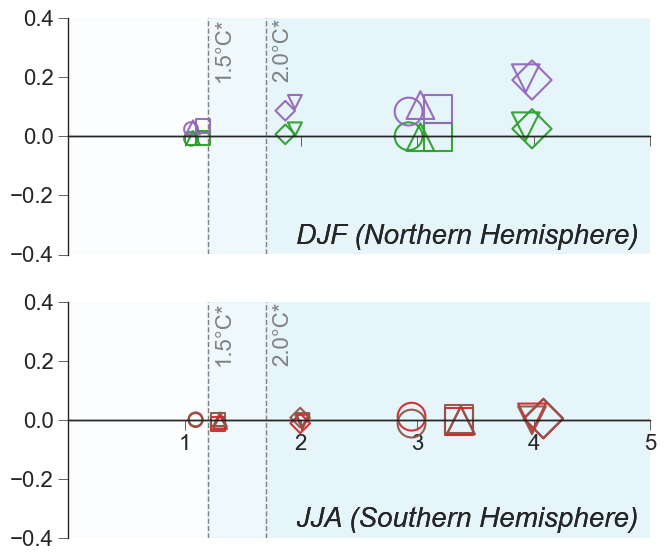

In [122]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSRunoff.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"].isin(["126_Longterm", "585_Longterm"])]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Longterm': 100,   # Smaller size for 126_Midterm
    '585_Longterm': 400    # Larger size for 585_Midterm
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "DJF: Northern Hemisphere"
    },
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "JJA: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_mm/day"]
data_max = max(x_all.max(), y_all.max(), 2.0)

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
    ax.axvspan(1.7, 5.0, alpha=1.0, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # Get size based on period
            size = period_sizes.get(row["Period"], 40)
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_mm/day"],
                marker=marker,
                s=size,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95
            )

    x_max = 5
    y_min = -0.4
    y_max = 0.4
    xticks = np.arange(1, x_max + 0.01, 1)
    yticks = np.arange(y_min, y_max + 0.01, 0.2)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    # === REMOVE FRAME - keep only X and Y axes ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Keep baseline at Y=0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

    # Move X-axis and its labels to Y=0
    ax.spines['bottom'].set_position('zero')  # Move X-axis to Y=0
    ax.tick_params(axis='x', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)
    ax.tick_params(axis='y', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)

    # Inline labels at end of lines
    ax.text(1.2 + 0.05, 0.4, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
    ax.text(1.7 + 0.05, 0.4, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1)

    #ax.set_title(setting["title"], fontsize=16)

    # === ANNOTATIONS FOR SEASONS ===
    axs[0].text(0.98, 0.02, 'DJF (Northern Hemisphere)', transform=axs[0].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')
    axs[1].text(0.98, 0.02, 'JJA (Southern Hemisphere)', transform=axs[1].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')

    ax.grid(False)

# === Shared Legend BELOW plots ===
region_legend = [
    Line2D([0], [0], marker='o', color='w', label=region,
           markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
    for region, color in region_colors.items()
]

reference_legend = [
    Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limit (1.5°C and 2.0°C)"),
    Line2D([0], [0], color='black', linestyle='-', label="Y=0 Baseline"),
]

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_Temp_vs_q_Winter2.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_Temp_vs_q_Winter2.png'")
plt.show()

Figure saved as 'Global_Temp_vs_q_Summer2.png'


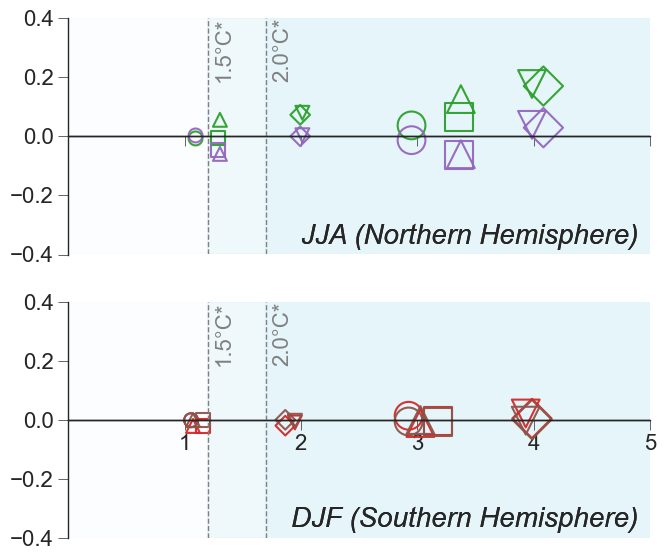

In [121]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
plt.ion()

plt.rcParams.update({
    'font.family': 'Arial',  # Nature prefers Arial/Helvetica
})

# === FILE PATH ===
file_path = "Tas_SeasonalVSRunoff.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")
df.columns = df.columns.str.strip()

# Filter for Historical period and valid regions
df = df[df["Period"].isin(["126_Longterm", "585_Longterm"])]

# === REGION COLORS & MARKERS ===
model_markers = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
    'ERA5': 'p'             # Changed from 's' to pentagon
}

# === PERIOD SIZES ===
period_sizes = {
    '126_Longterm': 100,   # Smaller size for 126_Midterm
    '585_Longterm': 400    # Larger size for 585_Midterm
}

region_colors = {
    'Subtropics_N': '#2ca02c',
    'Subtropics_S': '#d62728',
    'Mid_Latitudes_N': '#9467bd',
    'Mid_Latitudes_S': '#8c564b'
}

# === SETUP SUBPLOTS ===
sns.set(style="ticks", context="talk")
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)

subplot_settings = [
    {
        "season": "JJA",
        "regions": ["Mid_Latitudes_N", "Subtropics_N"],
        "ax": axs[0],
        "title": "JJA: Northern Hemisphere"
    },
    {
        "season": "DJF",
        "regions": ["Mid_Latitudes_S", "Subtropics_S"],
        "ax": axs[1],
        "title": "DJF: Southern Hemisphere"
    }
]

# Determine axis limits globally
x_all = df["Global_Temp_change_°C"]
y_all = df["Regional_change_mm/day"]
data_max = max(x_all.max(), y_all.max(), 2.0)

for i, setting in enumerate(subplot_settings):
    sub_df = df[(df["Season"] == setting["season"]) & (df["Region"].isin(setting["regions"]))]
    ax = setting["ax"]
    sub_df["Region"] = pd.Categorical(sub_df["Region"], categories=setting["regions"], ordered=True)

    # === ADD BACKGROUND COLOR REGIONS FOR EACH SUBPLOT ===
    # Light red background for 0 < X < 1.2
    ax.axvspan(0, 1.2, alpha=0.1, color='#e5f5f9', zorder=0)
    # Darker red background for 1.2 < X < 1.5
    ax.axvspan(1.2, 1.7, alpha=0.6, color='#e5f5f9', zorder=0)
    ax.axvspan(1.7, 5.0, alpha=1.0, color='#e5f5f9', zorder=0)

    for model, marker in model_markers.items():
        model_df = sub_df[sub_df["Model"] == model]
        for _, row in model_df.iterrows():
            color = region_colors.get(row["Region"], "gray")
            
            # Get size based on period
            size = period_sizes.get(row["Period"], 40)
            
            # All markers are unfilled (outline only)
            ax.scatter(
                row["Global_Temp_change_°C"],
                row["Regional_change_mm/day"],
                marker=marker,
                s=size,
                edgecolor=color,
                facecolor='none',  # No fill for all markers
                linewidth=1.5,     # Slightly thicker edge for better visibility
                alpha=0.95
            )

    x_max = 5
    y_min = -0.4
    y_max = 0.4
    xticks = np.arange(1, x_max + 0.01, 1)
    yticks = np.arange(y_min, y_max + 0.01, 0.2)
    yticks = np.append(yticks, 0)
    yticks = np.unique(yticks)

    ax.set_xlim(0, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    # === REMOVE FRAME - keep only X and Y axes ===
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.0)
    
    # Keep baseline at Y=0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

    # Move X-axis and its labels to Y=0
    ax.spines['bottom'].set_position('zero')  # Move X-axis to Y=0
    ax.tick_params(axis='x', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)
    ax.tick_params(axis='y', which='major', length=7, width=0.5, direction='out', 
                   labelsize=16)

    # Inline labels at end of lines
    ax.text(1.2 + 0.05, 0.4, '1.5°C*', color='gray', fontsize=16, rotation=90, va='top')
    ax.text(1.7 + 0.05, 0.4, '2.0°C*', color='gray', fontsize=16, rotation=90, va='top')

    ax.axvline(x=1.2, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=1.7, color='gray', linestyle='--', linewidth=1)

    #ax.set_title(setting["title"], fontsize=16)

    # === ANNOTATIONS FOR SEASONS ===
    axs[0].text(0.98, 0.02, 'JJA (Northern Hemisphere)', transform=axs[0].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')
    axs[1].text(0.98, 0.02, 'DJF (Southern Hemisphere)', transform=axs[1].transAxes,
           fontsize=20, ha='right', va='bottom', style='italic')

    ax.grid(False)

# === Shared Legend BELOW plots ===
region_legend = [
    Line2D([0], [0], marker='o', color='w', label=region,
           markerfacecolor='none', markeredgecolor=color, markersize=6, linestyle='None')
    for region, color in region_colors.items()
]

reference_legend = [
    Line2D([0], [0], color='gray', linestyle='--', label="IPCC Limit (1.5°C and 2.0°C)"),
    Line2D([0], [0], color='black', linestyle='-', label="Y=0 Baseline"),
]

# === Adjust Layout ===
plt.subplots_adjust(hspace=0.2)
plt.tight_layout(rect=[0, 0.01, 1, 1])  # Leave space for legend
plt.savefig("Global_Temp_vs_q_Summer2.png", dpi=800, bbox_inches='tight')
print("Figure saved as 'Global_Temp_vs_q_Summer2.png'")
plt.show()